
# 第二章
`原著: Cam Davidson-Pilon`

`Python 3 / PyMC3 移植: Max Margenot (@clean_utensils), Thomas Wiecki (@twiecki), Quantopian`

`PyMC (最新) 移植: Kurisu Chan (@miemiekurisu)`

`中文翻译、现代 PyMC (6.x) 适配与内容增补: 本 fork 维护者`

___

本章会介绍更多 PyMC 的语法和变量用法,以及如何从贝叶斯视角为一个系统建模的思路。同时也会介绍一些评估贝叶斯模型拟合优度(goodness-of-fit)的实用技巧和数据可视化方法。

**本章的现代 PyMC 修复说明**:原书这一章多处使用了 `model.initial_values` 这个已被废弃的属性(在现在的 PyMC 里已不存在),我们统一替换为现代 API `model.initial_point()`。二者含义略有差别: 旧的 `initial_values` 只是直接回显你通过 `initval=` 传入的原始参数(没设置就是 `None`);新的 `initial_point()` 则会返回 PyMC 真正用来启动采样的、具体的起始数值(即便你没有手动设置 `initval`,也会显示自动初始化后的结果),并且会显示变量在**内部采样空间**里的名字(比如正数约束的变量会带有 `_log__` 后缀,因为 PyMC 在底层是在对数空间里采样这个变量,再变换回原始空间)——这其实是比旧写法更准确、信息量也更大的现代等价物。



## 再多聊聊 PyMC

### 模型上下文 (Model Context)

在 PyMC 中,我们通常会把想要放进模型里的所有变量,都放在 `Model` 对象的上下文(context)中来处理。


In [1]:

import pymc as pm
import pytensor
import numpy as np
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
# %config InlineBackend.figure_format = 'retina'
# 正确的初始化方式是使用 initval 参数
# test_value 只是用来调试的
# 参考 https://pytensor.readthedocs.io/en/latest/tutorial/debug_faq.html#using-test-values
# 以及 https://github.com/pymc-devs/pymc/issues/562#issuecomment-932146862
# 调试时可以用 pytensor.config.compute_test_value = 'warn'
with pm.Model() as model:
    parameter = pm.Exponential("poisson_param", 1.0, initval=rng.exponential(1))
    data_generator = pm.Poisson("data_generator", parameter)



和普通 PyMC 变量相比,这是一层额外的便利机制。任何在某个 `Model` 上下文中创建的变量,都会自动关联到那个模型上。如果你试图在模型上下文之外定义一个变量,就会得到一个报错。

我们可以用 `with` 加上已有模型对象的名字,继续在同一个模型的上下文中工作。


In [2]:

with model:
    data_plus_one = data_generator + 1



一旦变量定义好了,我们就可以在模型上下文*之外*查看它们;但如果要定义更多能被模型识别的新变量,就必须在上下文*之内*进行。


In [3]:

model.initial_point()


{'poisson_param_log__': array(0.36864242), 'data_generator': array(1)}


关联到某个模型上的每一个变量,都会用它自己的名字来定义(也就是构造函数的第一个字符串参数,我们会在"变量"一节详细讨论)。如果想创建一个和之前用过的模型同名的新模型对象,只需要重新运行第一段代码即可。


In [4]:

with pm.Model() as model_exp:
    theta = pm.Exponential("theta", 2.0)
    data_generator = pm.Poisson("data_generator", theta)



我们也可以定义一个完全独立的模型。注意我们可以随意给模型命名,所以如果不想覆盖掉旧模型,只需要再建一个新的就行。


In [5]:

with pm.Model() as ab_testing:
    p_A = pm.Uniform("P(A)", 0, 1)
    p_B = pm.Uniform("P(B)", 0, 1)



你可能已经注意到,给模型添加变量时,PyMC 常常会给出关于"变换"(transformation)的提示信息。这些变换是 PyMC 在内部对变量采样所在的空间做的修改(等到我们真正对模型采样时会用到)。这是一个内部特性,有助于让采样结果更好地收敛到后验分布,并改善最终结果——这也正是上面 `model.initial_point()` 输出里,那些约束变量名字带有 `_log__`/`_interval__` 之类后缀的原因:PyMC 把"必须为正"或"必须落在某个区间"这类约束,转换成了在一个不受约束的实数空间里采样,这样采样器工作起来更顺畅,最后再变换回原始空间给用户看。



### PyMC 变量

所有的 PyMC 变量都有一个初始值,如果你没有显式指定 `initval` 参数,PyMC 之后会自动为你初始化。

用之前的变量为例:


In [6]:

# 交给 PyMC 自动初始化
with pm.Model() as model:
    parameter = pm.Exponential("poisson_param", 1.0)
    data_generator = pm.Poisson("data_generator", parameter)


In [7]:

for k, v in model.initial_point().items():
    print(f"{k} 的初始值是 {v}")


poisson_param_log__ 的初始值是 0.0
data_generator 的初始值是 1


In [8]:

# 交给 PyMC 自动初始化
with pm.Model() as model:
    parameter = pm.Exponential("poisson_param", 1.0, initval=rng.exponential(1))
    data_generator = pm.Poisson("data_generator", parameter, initval=rng.poisson(10))


In [9]:

for k, v in model.initial_point().items():
    print(f"{k} 的初始值是 {v}")


poisson_param_log__ 的初始值是 0.8152326091823561
data_generator 的初始值是 10



`initval` 参数仅仅用于模型——它是采样的起始点,前提是没有另外指定其他起始点。它并不会随着采样的进行而改变。


In [10]:

with pm.Model() as model:
    parameter = pm.Exponential("poisson_param", 1.0, initval=0.5)

# 可以用 initial_point() 查看上面所有参数的初始值
model.initial_point()


{'poisson_param_log__': array(-0.69314718)}


如果你用的是一个不太稳定、可能需要更好起始点的先验,这个功能会很有帮助(正如上面 PyTensor 文档链接里提到的,这在调试时也很有用)。

PyMC 关心两类编程变量:随机变量(stochastic)和确定性变量(deterministic)。

- *随机变量*指的是那些不是确定性的变量,也就是说,即使你知道了这个变量所有的参数和组成部分的取值,它依然是随机的。属于这一类的包括 `Poisson`、`DiscreteUniform`、`Exponential` 等类的实例。

- *确定性变量*指的是那些一旦知道了它的参数和组成部分的取值,自身就不再是随机的变量。这一点一开始可能有点让人困惑,一个快速的判断方式是:*如果我知道了变量 `foo` 的所有组成变量,我就能确定 `foo` 的值*。

下面我们分别详细介绍这两类变量。

#### 初始化随机变量

初始化一个随机(random)变量,需要一个 `name` 参数,再加上一些该类特有的额外参数。例如:

`some_variable = pm.DiscreteUniform("discrete_uni_var", 0, 4)`

其中 0 和 4 是 `DiscreteUniform` 特有的、随机变量的下界和上界。[PyMC 文档](https://docs.pymc.io/en/stable/api.html)里列出了各类随机变量的具体参数(如果你在用 IPython,也可以用 `??` 查看)。

`name` 属性在分析后期用于取回对应变量的后验分布,所以最好用一个有描述性的名字。通常我会直接用 Python 变量名作为 `name`。

对于多变量问题,与其创建一个由随机变量组成的 Python 数组,不如在调用随机变量时使用 `shape` 关键字,这样就能一次性创建一个由(相互独立的)随机变量组成的多维数组。这个数组在使用时和 NumPy 数组类似,访问其 `initval` 属性也会返回 NumPy 数组。

`shape` 参数还能解决另一个烦人的情形:假设你想为很多个变量 $\beta_i,\; i=1,\dots,N$ 建模。与其像下面这样为每一个变量起一个随意的名字:

    beta_1 = pm.Uniform("beta_1", 0, 1)
    beta_2 = pm.Uniform("beta_2", 0, 1)
    ...

不如把它们包装成一个变量:

    betas = pm.Uniform("betas", 0, 1, shape=N)



#### 确定性变量

创建确定性变量的方式和创建随机变量类似。我们只需要调用 PyMC 的 `Deterministic` 类,并传入我们想要的函数:

    deterministic_variable = pm.Deterministic("deterministic variable", some_function_of_variables)

在各种场合下,我们都可以把对象 `some_deterministic_var` 当成一个变量,而不是一个 Python 函数来使用。

调用 [`pymc.Deterministic`](https://www.pymc.io/projects/docs/en/latest/api/generated/pymc.Deterministic.html?highlight=Deterministic) 是最直接的创建确定性变量的方式,但并不是唯一的方式。加法、指数运算等基本操作会隐式地创建确定性变量。例如,下面这行代码会返回一个确定性变量:


In [11]:

with pm.Model() as model:
    lambda_1 = pm.Exponential("lambda_1", 1.0, initval=0.5)
    lambda_2 = pm.Exponential("lambda_2", 1.0, initval=0.5)
    tau = pm.DiscreteUniform("tau", lower=0, upper=10)

new_deterministic_variable = lambda_1 + lambda_2



不过,如果我们希望一个 `deterministic` 变量真正被采样过程追踪记录下来,就需要用构造函数把它显式地定义成一个具名的 `deterministic` 变量。

上一章的短信例子中就出现过这种用法。回忆一下,$\lambda$ 的模型长这样:

$$
\lambda =
\begin{cases}\lambda_1  & \text{if } t \lt \tau \cr
\lambda_2 & \text{if } t \ge \tau
\end{cases}
$$

对应的 PyMC 代码是:


In [12]:

import numpy as np

n_data_points = 5  # 第一章里我们大约有 70 个数据点
idx = np.arange(n_data_points)
with model:
    lambda_ = pm.math.switch(tau >= idx, lambda_1, lambda_2)



显然,如果 $\tau, \lambda_1, \lambda_2$ 都已知,那么 $\lambda$ 也就完全确定了,所以它是一个确定性变量。这里我们用 `switch` 函数,在合适的时机从 $\lambda_1$ 切换到 $\lambda_2$。这个函数直接来自 `pytensor.tensor.basic` 包,我们会在下一节详细讨论它。

在一个 `deterministic` 变量内部,传入的随机变量表现得就像标量或者(多变量情形下)NumPy 数组一样。只要维度能对得上,我们可以对它们做任何运算。

举例来说,运行下面这段代码(当然,前提是你已经先定义好了模型会话):

    def subtract(x, y):
        return x - y
    with model:
        stochastic_1 = pm.Uniform("U_1", 0, 1)
        stochastic_2 = pm.Uniform("U_2", 0, 1)

        det_1 = pm.Deterministic("Delta", subtract(stochastic_1, stochastic_2))

是完全合法的 PyMC 代码。不过说"我们的表达式表现得像 NumPy 数组"其实不完全准确。这里的关键点在于,我们构造的表达式*必须*和 `pytensor` 张量兼容,这一点我们会在下一节详细介绍。你可以自由地定义任何需要的函数来组合你的模型,但如果需要做任何类似数组运算的操作(通常会用到 NumPy 函数),请确保改用它们在 `pytensor` 里的等价写法。



### PyTensor

PyMC 背后的大部分繁重计算,都是由 `pytensor` 包来完成的,它是 `theano` 的下一代继任者。`pytensor` 的记号和 NumPy 非常相似,也支持许多我们熟悉的 NumPy 计算元素。但不同的是,NumPy 会直接执行计算(比如运行 `a + b` 时立即算出结果),而 `pytensor` 则会先构建出一张"计算图"(compute graph),记录下你想对元素 `a` 和 `b` 执行 `+` 操作这件事本身。只有当你对一个 `pytensor` 表达式调用 `eval()` 时,真正的计算才会发生(也就是说,`pytensor` 是*惰性求值*的)。一旦计算图构建完成,我们就可以对它做各种数学优化(比如化简)、通过自动微分计算梯度、把整张图编译成 C 代码以机器码速度运行,甚至编译到 GPU 上运行。从本质上说,PyMC 就是把各种概率分布用 `pytensor` 的符号表达式表示出来,再组合成一张描述整个模型对数概率的大计算图,外加一套利用这张图计算概率和梯度的推断算法集合。这对我们的实际影响是:要搭建某些模型时,有时我们必须直接使用 `pytensor`。

让我们写一些涉及 `pytensor` 运算的 PyMC 代码。


In [13]:

import pytensor.tensor as pt

with pm.Model() as pytensor_test:
    p1 = pm.Uniform("p", 0, 1)
    p2 = 1 - p1
    p = pt.stack([p1, p2])

    assignment = pm.Categorical("assignment", p)



这里我们用 `pytensor` 的 `stack()` 函数,方式和用 NumPy 的堆叠函数类似:把两个独立的变量 `p1` 和 `p2` 合并成一个含有 2 个元素的向量。如果我们直接把 `p1` 和 `p2` 打包成一个 NumPy 数组传给随机变量 `categorical`,它是无法理解我们意图的,因为 `p1`、`p2` 本身都是 `pytensor` 变量。像这样把它们堆叠起来,就把它们合并成了一个 `pytensor` 变量,可以直接作为两个类别互补的概率对来使用。

在本书接下来的部分,我们会多次用到 `pytensor` 的各种函数来辅助构建模型。如果你对 `pytensor` 本身更感兴趣,可以查阅它的[官方文档](https://pytensor.readthedocs.io/en/latest/)。

聊完这些技术细节之后,让我们回到模型的构建上来!



### 把观测数据纳入模型

到这一步,虽然看起来还不明显,但我们其实已经完整地指定好了先验。举例来说,我们可以提出并回答这样的问题:"$\lambda_1$ 的先验分布长什么样?"


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2882299/2378424664.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.title("$\lambda_1$ 的先验分布")


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5148' [U+5148], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5148' [U+5148], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


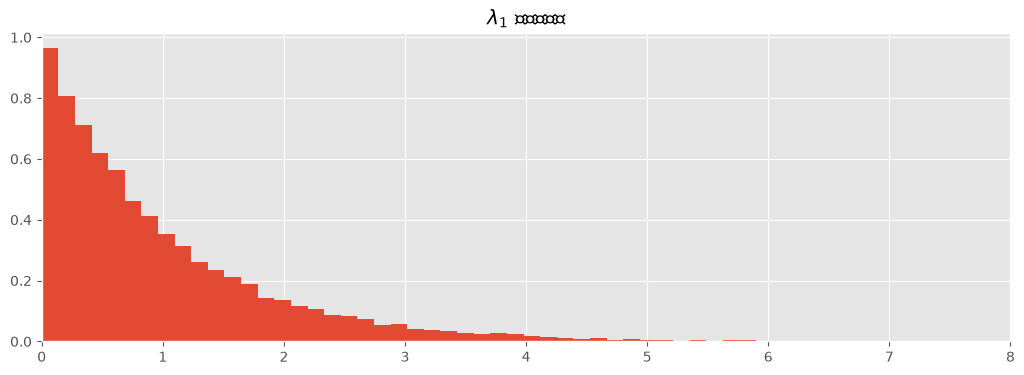

In [14]:

%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import scipy.stats as stats
figsize(12.5, 4)
plt.style.use("ggplot")
samples = pm.draw(lambda_1, draws=20000)
plt.hist(samples, bins=70, density=True, histtype="stepfilled")
plt.title("$\lambda_1$ 的先验分布")
plt.xlim(0, 8);



借用第一章的记号(虽然这算是对记号略有些滥用),我们相当于已经指定了 $P(A)$。我们下一个目标,是把数据/证据/观测值 $X$ 纳入模型。

PyMC 的随机变量有一个关键字参数 `observed`。这个 `observed` 关键字的作用非常简单:把变量的当前值固定为给定的数据,通常是一个 NumPy 的 `array` 或者 pandas 的 `DataFrame`。例如:


In [15]:

data = np.array([10, 5])
with model:
    fixed_variable = pm.Poisson("fxd", 1, observed=data)
print(model.initial_point())


{'lambda_1_log__': array(-0.69314718), 'lambda_2_log__': array(-0.69314718), 'tau': array(5)}



这就是我们把数据纳入模型的方式:把一个随机变量初始化为一个*固定值*。

为了完成上一章的短信例子,我们把 PyMC 变量 `observations` 固定为观测到的数据集。


In [16]:

# 这里我们用一些虚构的数据
data = np.array([10, 25, 15, 20, 35])
with model:
    obs = pm.Poisson("obs", lambda_, observed=data)
print(model.initial_point())


{'lambda_1_log__': array(-0.69314718), 'lambda_2_log__': array(-0.69314718), 'tau': array(5)}



## 建模的思路

进行贝叶斯建模时,一个很好的出发点是思考*你的数据可能是怎样生成的*。把自己放在一个"全知视角",试着想象*你自己*会如何重现这份数据集。

在上一章,我们分析了短信数据。我们是这样开始思考观测数据可能是如何生成的:

1. 我们先问自己:"用什么随机变量来描述这种计数数据最合适?"泊松随机变量是一个很好的候选,因为它可以表示计数型数据。所以我们把每天收到的短信条数,建模为从泊松分布中采样得到的。

2. 接下来我们想:"好,假设短信条数服从泊松分布,那泊松分布还需要什么呢?"泊松分布有一个参数 $\lambda$。

3. 我们知道 $\lambda$ 吗?不知道。事实上,我们怀疑存在*两个*不同的 $\lambda$ 值,一个对应早期的行为模式,一个对应后期的行为模式。虽然我们不知道行为具体是什么时候切换的,但我们把这个切换点记为 $\tau$。

4. 两个 $\lambda$ 用什么分布比较合适?指数分布是个不错的选择,因为它为正实数分配概率。而指数分布本身也有一个参数,我们记为 $\alpha$。

5. 我们知道参数 $\alpha$ 大概是多少吗?不知道。这时候,我们本可以继续往下,再给 $\alpha$ 分配一个分布,但一旦达到了某种程度的"无知"就该及时收手:虽然我们对 $\lambda$ 抱有先验信念(比如"它可能会随时间变化"、"它很可能在 10 到 30 之间"),但我们对 $\alpha$ 并没有什么明确的信念。所以最好就此打住。

    那 $\alpha$ 取什么值比较好呢?我们认为 $\lambda$ 大概在 10 到 30 之间,所以如果把 $\alpha$ 设得非常低(意味着给较大的取值分配更高的概率),就没能很好地反映我们的先验信念。同理,$\alpha$ 太高也一样偏离了先验信念。一个能体现我们信念的好办法是:让在给定 $\alpha$ 时,$\lambda$ 的均值等于我们观测到的样本均值。上一章已经展示过如何做到这一点。

6. 我们没有任何专家意见能告诉我们 $\tau$ 大概发生在什么时候。所以我们假设 $\tau$ 服从整个观测时间段上的离散均匀分布。

下图给出了这个过程的图形化展示,箭头表示"父子"关系(由 [Daft Python 库](https://docs.daft-pgm.org/en/latest/) 提供)。

<img src="http://i.imgur.com/7J30oCG.png" width = 700/>

PyMC 以及其他概率编程语言,正是被设计用来讲述这类数据生成的*故事*的。B. Cronin [5] 写得更加宽泛:

> 概率编程将会解锁对数据的叙事性解释——这是商业分析领域的圣杯之一,也是科学说服力背后那位"无名英雄"。人们习惯以故事的方式思考——这正是逸闻趣事在驱动决策时拥有着不合理的强大影响力的原因,无论这种影响是否有充分依据。但现有的分析方法大多无法提供这样的故事;相反,数字仿佛凭空出现,几乎没有人类在权衡选项时更偏好的那种因果语境。



### 同一个故事,不同的结局

有意思的是,我们可以通过"倒着讲"这个故事来生成*新的数据集*。举例来说,如果把上面的步骤反过来,我们就可以模拟出一个数据集的可能实现。

1. 通过从 $\text{DiscreteUniform}(0, 80)$ 中采样,指定用户行为切换发生的时刻:


In [17]:

tau = np.random.randint(0, 80)
print(tau)


61



2. 从 $\text{Exp}(\alpha)$ 分布中采样得到 $\lambda_1$ 和 $\lambda_2$:


In [18]:

alpha = 1. / 20.
lambda_1, lambda_2 = np.random.exponential(scale=1 / alpha, size=2)
print(lambda_1, lambda_2)


1.8497093921083891 1.0321999755705855



3. 对 $\tau$ 之前的天数,从 $\text{Poi}(\lambda_1)$ 中采样来表示用户收到的短信条数;对 $\tau$ 之后的天数,则从 $\text{Poi}(\lambda_2)$ 中采样。例如:


In [19]:

data = np.r_[stats.poisson.rvs(mu=lambda_1, size=tau), stats.poisson.rvs(mu=lambda_2, size=80 - tau)]



4. 画出这份人工构造的数据集:


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

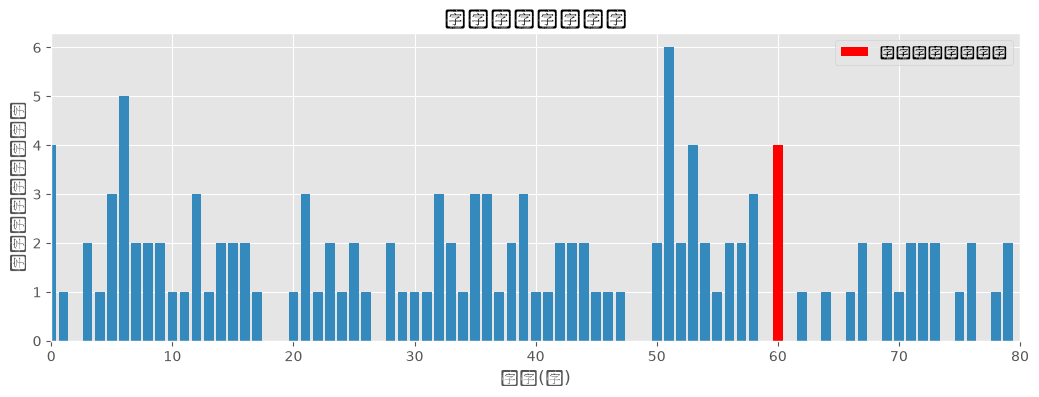

In [20]:

plt.bar(np.arange(80), data, color="#348ABD")
plt.bar(tau - 1, data[tau - 1], color="r", label="用户行为发生变化")
plt.xlabel("时间(天)")
plt.ylabel("当天收到的短信条数")
plt.title("人工构造的数据集")
plt.xlim(0, 80)
plt.legend();



我们虚构出来的数据集看起来和真实观测到的数据集不一样,这是完全正常的:它俩看起来一样的概率其实小得可怜。PyMC 的引擎正是被设计用来找出能让这个概率最大化的那组好参数 $\lambda_i, \tau$。

能够生成人工数据集,是我们建模过程中一个很有意思的副产物,我们后面会看到,这项能力其实是贝叶斯推断中非常重要的一种方法。下面我们再多生成几份数据集:


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


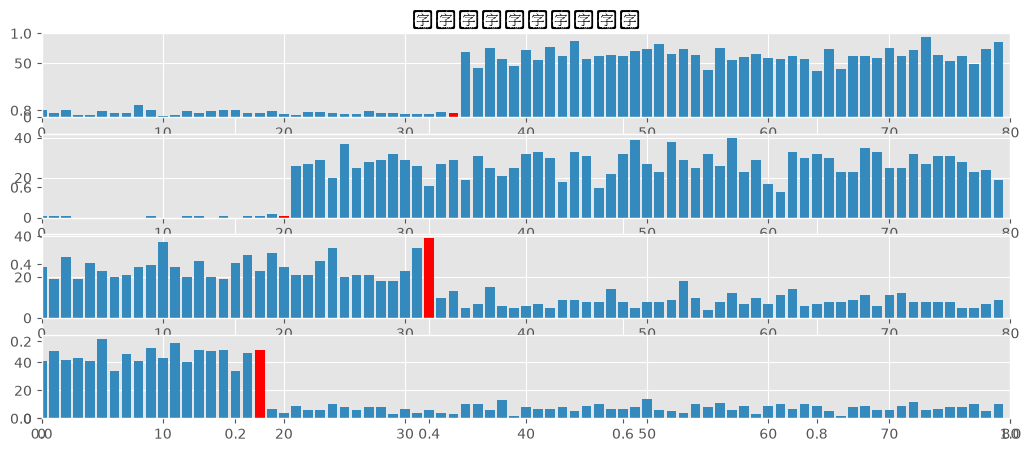

In [21]:

def plot_artificial_sms_dataset():
    tau = stats.randint.rvs(0, 80)
    alpha = 1. / 20.
    lambda_1, lambda_2 = stats.expon.rvs(scale=1 / alpha, size=2)
    data = np.r_[stats.poisson.rvs(mu=lambda_1, size=tau), stats.poisson.rvs(mu=lambda_2, size=80 - tau)]
    plt.bar(np.arange(80), data, color="#348ABD")
    plt.bar(tau - 1, data[tau - 1], color="r", label="用户行为发生变化")
    plt.xlim(0, 80);

figsize(12.5, 5)
plt.title("更多人工数据集的例子")
for i in range(4):
    plt.subplot(4, 1, i + 1)
    plot_artificial_sms_dataset()



之后我们会看到如何用这项技巧来做预测、检验模型是否合适。



##### 示例:贝叶斯 A/B 测试

A/B 测试是一种统计学上的设计范式,用来判断两种不同处理方案之间的效果差异。举例来说,一家制药公司想知道药物 A 和药物 B 哪个更有效。公司会在一部分试验对象上测试药物 A,在另一部分上测试药物 B(这个比例常常是 1/2,但我们不必局限于这个假设)。做了足够多的试验之后,公司内部的统计学家会梳理数据,判断哪种药物的效果更好。

类似地,前端网页开发者也想知道自己网站的哪种设计能带来更多的销售额,或者其他他们关心的指标。他们会把一部分访客导向网站 A,另一部分导向网站 B,并记录这次访问是否带来了一次购买。数据会被实时记录下来,并在之后进行分析。

通常,实验结束后的分析会用到所谓的假设检验,比如*均值差异检验*或*比例差异检验*。这会涉及一些常被误解的量,比如"Z 分数",以及更让人头疼的"p 值"(请不要问我)。如果你上过统计学课程,大概率被教过这项技术(但不一定真正*学会*了它)。如果你和我一样,大概也曾对它们的推导过程感到不太自在——很好,贝叶斯方法处理这个问题的方式自然得多。

### 一个简单的例子

既然这是一本"黑客风"的书,我们继续沿用网站开发的例子。先只关注网站 A 的分析。假设存在某个真实的概率 $0 \lt p_A \lt 1$,表示被展示网站 A 的用户最终会在网站上完成购买的比例。这就是网站 A 的真实转化效果,目前我们并不知道这个量具体是多少。

假设网站 A 被展示给了 $N$ 个人,其中有 $n$ 个人完成了购买。人们可能会草率地得出结论 $p_A = \frac{n}{N}$。可惜,*观测频率* $\frac{n}{N}$ 并不一定等于 $p_A$——*观测频率*和一个事件的*真实频率*之间是有区别的。真实频率可以理解为该事件发生的概率。例如,掷一个六面骰子掷出 1 的真实频率是 $\frac{1}{6}$。像这样的真实频率:

- 会完成购买的用户比例,
- 某种社会属性出现的频率,
- 拥有猫的网民所占的百分比,

都是我们经常想向"自然"提出的问题。可惜,自然常常把真实频率隐藏起来,我们必须从观测到的数据中把它*推断*出来。

那么*观测频率*就是我们实际观测到的频率:比如掷 100 次骰子,你可能观测到 20 次掷出 1。这个观测频率 0.2,和真实频率 $\frac{1}{6}$ 是不一样的。我们可以借助合适的先验和观测数据,用贝叶斯统计推断出真实频率可能的取值。

回到我们的 A/B 测试例子,我们希望利用已知的信息——$N$(总试验次数)和 $n$(转化次数)——来估计 $p_A$,即真实的购买者比例可能是多少。

要搭建一个贝叶斯模型,我们需要为未知量赋予先验分布。*先验地*来看,我们认为 $p_A$ 可能是多少?在这个例子里,我们对 $p_A$ 没有强烈的先验信念,所以暂且假设 $p_A$ 在 $[0,1]$ 上均匀分布:


In [22]:

import pymc as pm
# 这里的参数是 Uniform 分布的上下界。
with pm.Model() as model:
    p = pm.Uniform('p')  # , lower=0, upper=1)



如果我们对此有更强的先验信念,本可以把它们体现在上面的先验里。

在这个例子里,我们设 $p_A = 0.05$,并假设网站 A 被展示给了 $N = 1500$ 个用户,我们将模拟出这些用户是否完成了购买。要从 $N$ 次试验中模拟这个过程,我们会用到*伯努利*分布:如果 $X \sim \text{Ber}(p)$,那么 $X$ 以概率 $p$ 取值 1,以概率 $1-p$ 取值 0。当然,实际中我们并不知道 $p_A$,但这里我们会用它来生成模拟数据。


In [23]:

# 设定常数
p_true = 0.05  # 记住,这是我们不知道的
N = 1500

# 从 Ber(0.05) 中采样 N 个伯努利随机变量。
# 每个随机变量有 0.05 的概率取值为 1。
# 这一步就是数据生成的过程。
occurrences = stats.bernoulli.rvs(p_true, size=N)

print(occurrences)  # 记住: Python 里 True == 1, False == 0
print(np.sum(occurrences))


[0 0 0 ... 0 0 0]
65



观测频率是:


In [24]:

# occurrences.mean 就等于 n/N。
print("A 组观测到的频率是多少? %.4f" % np.mean(occurrences))
print("这等于真实频率吗? %s" % (np.mean(occurrences) == p_true))


A 组观测到的频率是多少? 0.0433
这等于真实频率吗? False



我们把观测数据整合进 PyMC 的 `observed` 变量,并运行我们的推断算法:


In [25]:

with model:
    observed = pm.Bernoulli("obs", p, observed=occurrences)


In [26]:

# 把观测数据(伯努利分布)纳入模型
with model:
    # 将在第三章解释
    step = pm.Metropolis()
    trace = pm.sample(18000, step=step, chains=3)  # chains 的默认值是 2, 这里独立跑 3 条链
    # 现代 PyMC 有一套新的数据结构来做 "burn-in"(丢弃预热期样本)
    # 如果用 return_inferencedata=False, 下面的旧写法依然能用,
    # 但既然有好用的 ArviZ, 我们就用现代默认值 True。
    # burned_trace = trace[1000:]


Multiprocess sampling (3 chains in 2 jobs)


Metropolis: [p]


Output()

Sampling 3 chains for 1_000 tune and 18_000 draw iterations (3_000 + 54_000 draws total) took 21 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



下面我们画出未知量 $p_A$ 的后验分布:


Font 'default' does not have a glyph for '\u7f51' [U+7f51], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7ad9' [U+7ad9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u771f' [U+771f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5b9e' [U+5b9e], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u771f' [U+771f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5b9e' [U+5b9e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u672a' [U+672a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u77e5' [U+77e5], substituting with a dummy symbol.


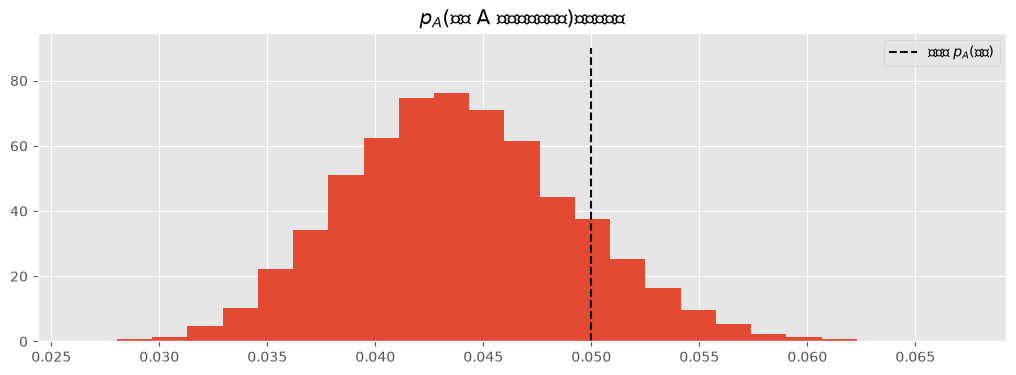

In [27]:

figsize(12.5, 4)
plt.title("$p_A$(网站 A 的真实转化效果)的后验分布")
plt.vlines(p_true, 0, 90, linestyle="--", label="真实的 $p_A$(未知)", color='black')
combine_3_chains = np.concatenate(trace.posterior.p.data[:, 1000:])
plt.hist(combine_3_chains, bins=25, histtype="stepfilled", density=True)
plt.legend();



我们的后验分布把大部分权重放在了真实 $p_A$ 值附近,但尾部也分配了一些权重。这体现了在已有观测数据的条件下,我们应当保有多大的不确定性。不妨试着改变观测数量 `N`,看看后验分布会如何变化。



新版 PyMC(>=4)提供了一个非常棒的可视化工具,叫做 `arviz`,可以用来分析采样轨迹:


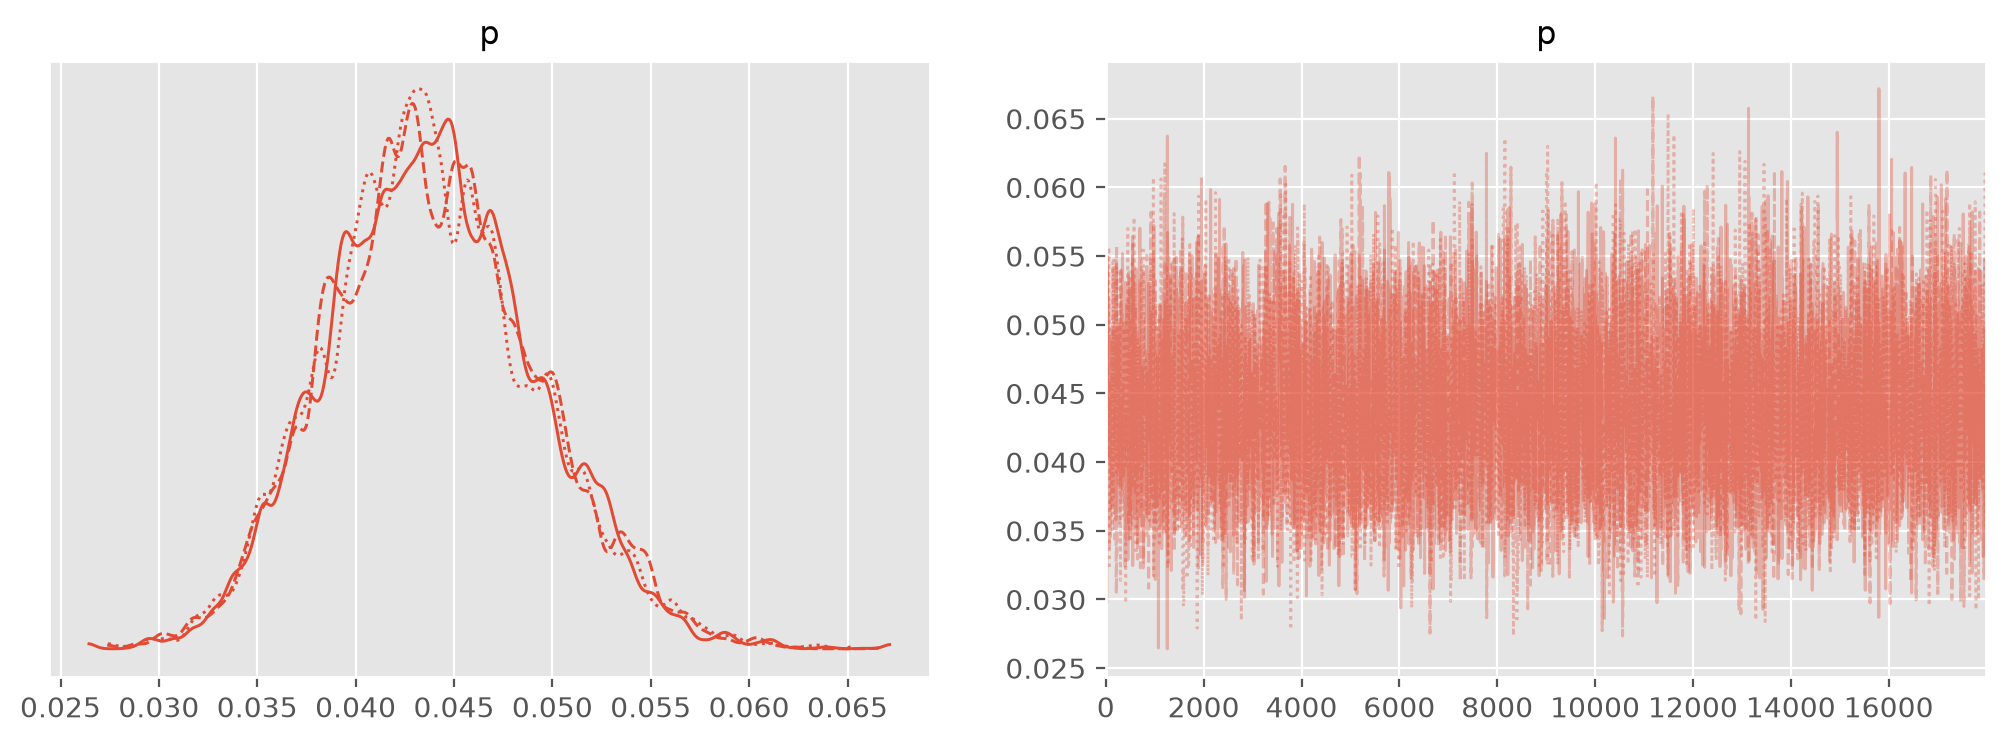

In [28]:

import arviz as az
%config InlineBackend.figure_format = 'retina'
# az.style.use("arviz-darkgrid")

az.plot_trace(trace, figsize=(12.5, 4));



可以清楚地看到上面三条独立的链。


[]

Font 'default' does not have a glyph for '\u7f51' [U+7f51], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7ad9' [U+7ad9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7f51' [U+7f51], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7ad9' [U+7ad9], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u771f' [U+771f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5b9e' [U+5b9e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u672a' [U+672a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u77e5' [U+77e5], substituting with a dummy symbol.


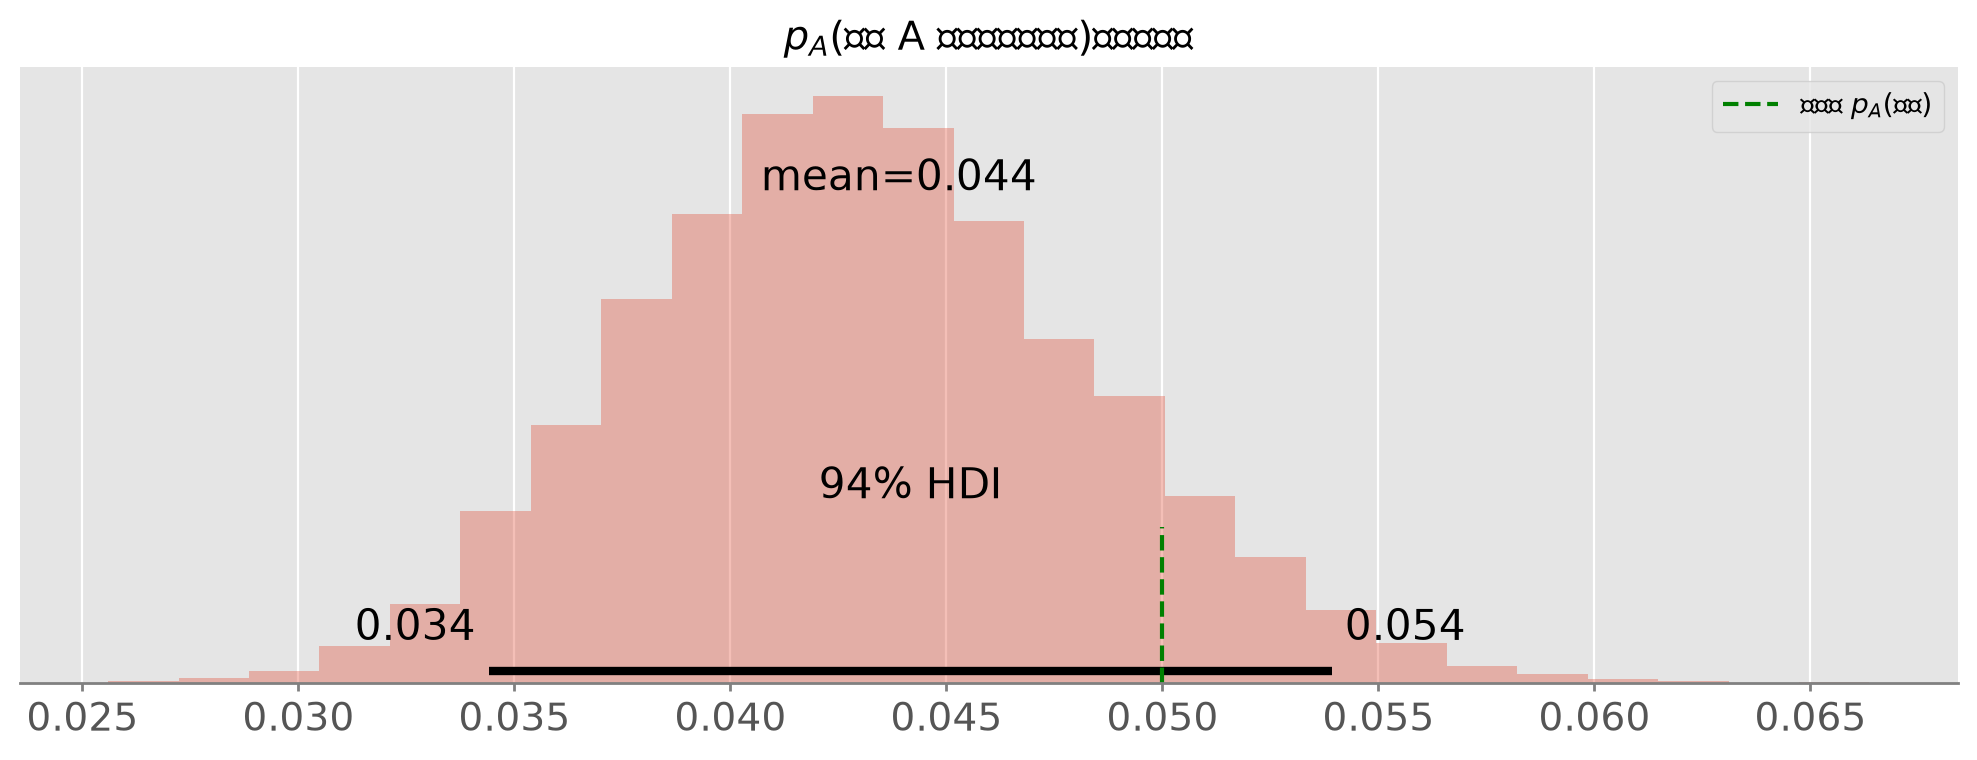

In [29]:

import matplotlib.lines as lines

ax = az.plot_posterior(trace, var_names=['p'], kind='hist', bins=25, figsize=(12.5, 4))
ax.set_title("$p_A$(网站 A 的真实转化效果)的后验分布")
ax.vlines(0.05, 0, 1800, colors='green', linestyle="--", label="真实的 $p_A$(未知)")
ax.legend()
ax.plot()



### 现代 PyMC 小贴士:收敛性诊断该看什么

在继续讲 *A* 和 *B* 一起分析之前,我们顺手用 `az.summary()` 看一眼上面这次采样的收敛性指标——这是原书没有的内容,但在现代 PyMC 工作流里几乎是标准动作,值得在这里养成习惯(第三章会更系统地介绍 MCMC 和这些诊断量背后的原理)。


In [30]:

az.summary(trace, var_names=["p"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.044,0.005,0.034,0.054,0.0,0.0,7872.0,7750.0,1.0



### *A* 和 *B* 一起分析

我们可以用类似的方式分析网站 B 的响应数据,得到对应的 $p_B$。但我们真正关心的,其实是 $p_A$ 和 $p_B$ 之间的*差异*。让我们一次性推断出 $p_A$、$p_B$,*以及* $\text{delta} = p_A - p_B$。我们可以借助 PyMC 的确定性变量来实现这一点。(这个练习中,我们假设 $p_B = 0.04$,所以 $\text{delta} = 0.01$,$N_B = 750$(明显少于 $N_A$),我们会像模拟网站 A 数据一样模拟网站 B 的数据。)


In [31]:

import pymc as pm
figsize(12, 4)

# 这两个量对我们来说是未知的。
true_p_A = 0.05
true_p_B = 0.04

# 注意样本量并不相等 —— 这在贝叶斯分析中完全没问题。
N_A = 1500
N_B = 750

# 生成一些观测数据
observations_A = stats.bernoulli.rvs(true_p_A, size=N_A)
observations_B = stats.bernoulli.rvs(true_p_B, size=N_B)
print("网站 A 的观测数据: ", observations_A[:30], "...")
print("网站 B 的观测数据: ", observations_B[:30], "...")


网站 A 的观测数据:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...
网站 B 的观测数据:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0] ...


In [32]:

print(np.mean(observations_A))
print(np.mean(observations_B))


0.056666666666666664
0.04133333333333333


In [33]:

# 建立 pymc 模型。同样假设 p_A、p_B 都是均匀先验。
with pm.Model() as model:
    p_A = pm.Uniform("p_A", 0, 1)
    p_B = pm.Uniform("p_B", 0, 1)

    # 定义确定性的 delta 函数。这是我们真正关心的未知量。
    delta = pm.Deterministic("delta", p_A - p_B)

    # 观测数据集合, 这里我们有两组独立的观测数据。
    obs_A = pm.Bernoulli("obs_A", p_A, observed=observations_A)
    obs_B = pm.Bernoulli("obs_B", p_B, observed=observations_B)

    # 将在第三章解释。
    step = pm.Metropolis()
    trace = pm.sample(20000, step=step, chains=2)
    # 如果用 return_inferencedata=False, 下面的旧写法依然能用,
    # 但既然有好用的 ArviZ, 我们就用现代默认值 True。
    # burned_trace=trace[1000:]


Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>Metropolis: [p_A]


>Metropolis: [p_B]


Output()

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


Sampling 2 chains for 1_000 tune and 20_000 draw iterations (2_000 + 40_000 draws total) took 19 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



下面我们画出这三个未知量的后验分布:


In [34]:

p_A_samples = np.concatenate(trace.posterior.p_A.data[:, 1000:])
p_B_samples = np.concatenate(trace.posterior.p_B.data[:, 1000:])
delta_samples = np.concatenate(trace.posterior.delta.data[:, 1000:])


Font 'default' does not have a glyph for '\u3001' [U+3001], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e0e' [U+4e0e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e09' [U+4e09], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e2a' [U+4e2a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u672a' [U+672a], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u771f' [U+771f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5b9e' [U+5b9e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u672a' [U+672a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u77e5' [U+77e5], substituting with a dummy symbol.


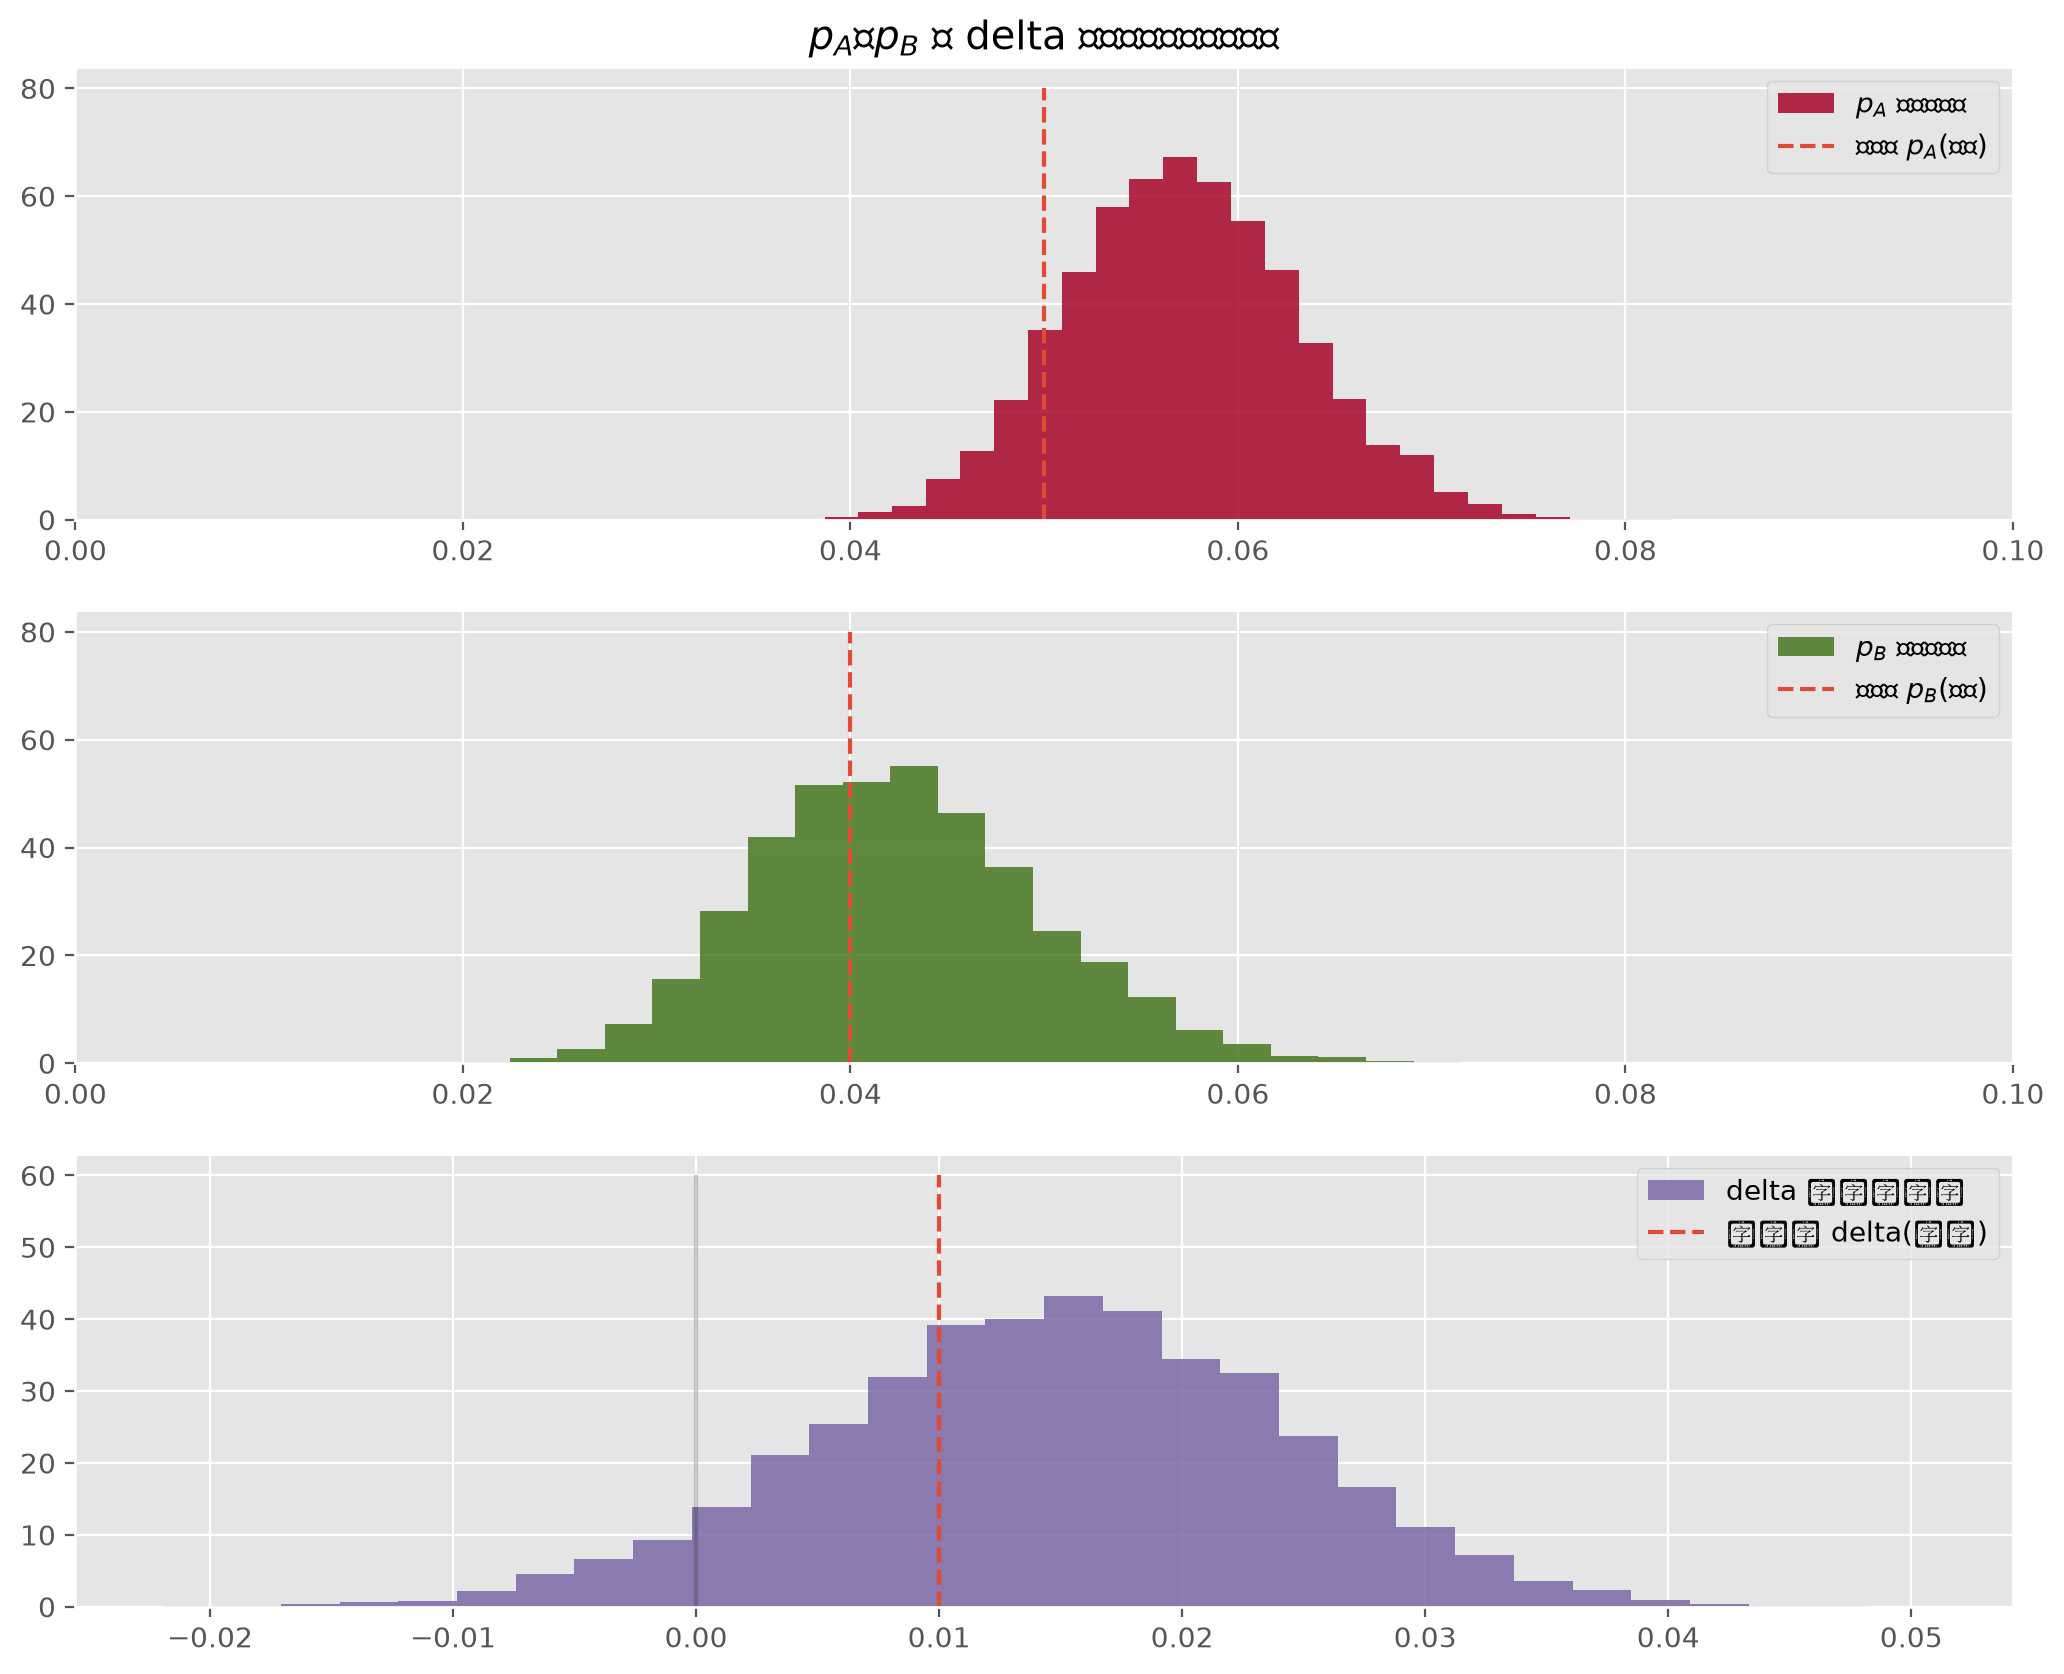

In [35]:

figsize(12.5, 10)

# 后验分布的直方图

ax = plt.subplot(311)

plt.xlim(0, .1)
plt.hist(p_A_samples, histtype='stepfilled', bins=25, alpha=0.85,
         label="$p_A$ 的后验分布", color="#A60628", density=True)
plt.vlines(true_p_A, 0, 80, linestyle="--", label="真实的 $p_A$(未知)")
plt.legend(loc="upper right")
plt.title("$p_A$、$p_B$ 与 delta 三个未知量的后验分布")

ax = plt.subplot(312)

plt.xlim(0, .1)
plt.hist(p_B_samples, histtype='stepfilled', bins=25, alpha=0.85,
         label="$p_B$ 的后验分布", color="#467821", density=True)
plt.vlines(true_p_B, 0, 80, linestyle="--", label="真实的 $p_B$(未知)")
plt.legend(loc="upper right")

ax = plt.subplot(313)
plt.hist(delta_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label="delta 的后验分布", color="#7A68A6", density=True)
plt.vlines(true_p_A - true_p_B, 0, 60, linestyle="--",
           label="真实的 delta(未知)")
plt.vlines(0, 0, 60, color="black", alpha=0.2)
plt.legend(loc="upper right");



注意到,由于 `N_B < N_A`,也就是说我们从网站 B 得到的数据更少,$p_B$ 的后验分布更"胖"一些,这说明相比 $p_A$,我们对 $p_B$ 真实值的把握更小。

再看 $\text{delta}$ 的后验分布,可以看到分布的大部分都位于 $\text{delta}=0$ 之上,这说明网站 A 的表现很可能优于网站 B。这个推断出错的概率也很容易算出来:


In [36]:

# 统计小于 0 的样本数量, 也就是 0 之前那部分曲线下的面积,
# 代表网站 A 比网站 B 差的概率。
print("网站 A 比网站 B 差的概率: %.3f" %
      np.mean(delta_samples < 0))

print("网站 A 比网站 B 好的概率: %.3f" %
      np.mean(delta_samples > 0))


网站 A 比网站 B 差的概率: 0.062
网站 A 比网站 B 好的概率: 0.938



如果这个概率高到让人无法安心做决策,我们可以在网站 B 上多做一些试验(因为网站 B 起始样本量更少,每多一个数据点,给网站 B 带来的推断"效力"就比给网站 A 带来的更大)。

不妨试着调整参数 `true_p_A`、`true_p_B`、`N_A`、`N_B`,看看 $\text{delta}$ 的后验分布会怎么变化。注意在整个过程中,我们从未特意提到"网站 A 和网站 B 样本量不同"这件事——它自然而然地就融入了贝叶斯分析当中。

我希望读者会觉得这种 A/B 测试的方式,比传统的假设检验更自然——后者带给从业者的困惑,恐怕比帮助还多。本书后面会介绍这个模型的两个扩展:第一个能帮助我们动态地调整表现不佳的网站,第二个则会把整个分析简化成一个方程,从而提升计算速度。



## 一个应对人类"说谎"的算法

社会调查数据还多了一层复杂性,因为人们的回答并不总是诚实的,这给推断又增加了一重困难。举例来说,如果你直接问受访者"你有没有在考试中作弊过?",答案里必然会掺杂一定程度的不诚实。可以确定的一点是,真实的作弊率一定*低于*观测到的作弊率(假设人们只会在"没作弊"这件事上撒谎;我很难想象有人会在实际没作弊的情况下,承认自己"作弊了")。

为了给这个"不诚实"问题提供一个优雅的解决方案,同时展示贝叶斯建模的威力,我们首先需要介绍二项分布。

### 二项分布

二项分布是最常用的分布之一,主要是因为它简单又实用。和本书目前遇到的其他分布不同,二项分布有 2 个参数:$N$,一个正整数,表示 $N$ 次试验或者潜在事件发生的次数;以及 $p$,单次试验中事件发生的概率。和泊松分布一样,它也是一个离散分布,但和泊松分布不同的是,它只对 $0$ 到 $N$ 之间的整数分配概率。它的质量分布长这样:

$$P( X = k ) =  {{N}\choose{k}}  p^k(1-p)^{N-k}$$

如果 $X$ 是一个参数为 $p$、$N$ 的二项随机变量,记作 $X \sim \text{Bin}(N,p)$,那么 $X$ 就是 $N$ 次试验中事件发生的次数(显然 $0 \le X \le N$)。$p$ 越大(同时保持在 0 到 1 之间),事件发生的可能性就越高。二项分布的期望值等于 $Np$。下面我们画出不同参数下的质量概率分布。


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 39033 (\N{CJK UNIFIED IDEOGRAPH-9879}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

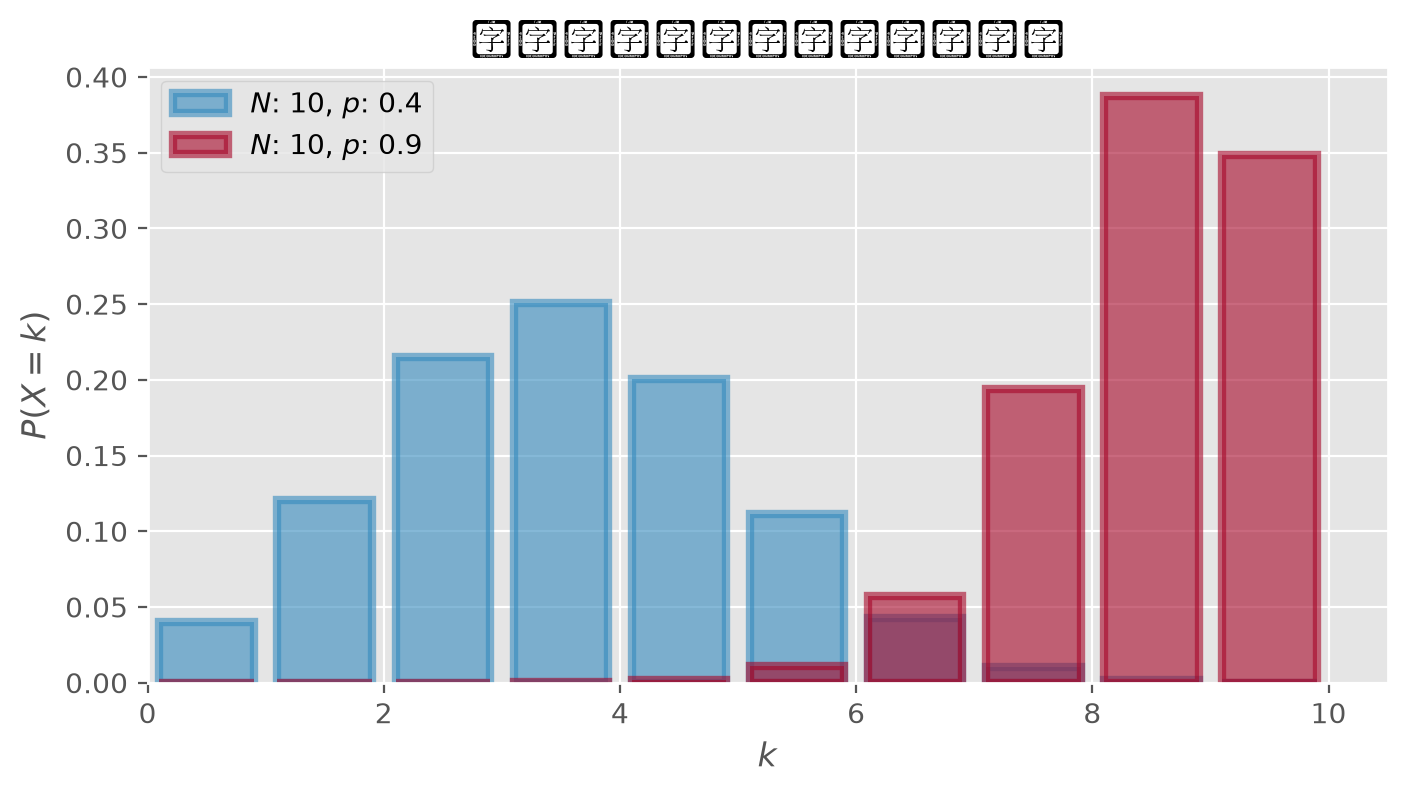

In [37]:

figsize(8, 4)

import scipy.stats as stats
binomial = stats.binom

parameters = [(10, .4), (10, .9)]
colors = ["#348ABD", "#A60628"]

for i in range(2):
    N, p = parameters[i]
    _x = np.arange(N + 1)
    plt.bar(_x - 0.5, binomial.pmf(_x, N, p), color=colors[i],
            edgecolor=colors[i],
            alpha=0.6,
            label="$N$: %d, $p$: %.1f" % (N, p),
            linewidth=3)

plt.legend(loc="upper left")
plt.xlim(0, 10.5)
plt.xlabel("$k$")
plt.ylabel("$P(X = k)$")
plt.title("二项随机变量的概率质量分布");



$N=1$ 是一种特殊情形,对应伯努利分布。伯努利随机变量和二项随机变量之间还有另一层联系:如果 $X_1, X_2, \dots, X_N$ 是参数相同(都是 $p$)的伯努利随机变量,那么 $Z = X_1 + X_2 + \dots + X_N \sim \text{Binomial}(N, p)$。

伯努利随机变量的期望值是 $p$。这一点也可以从更一般的二项随机变量的期望值 $Np$ 出发,令 $N=1$ 得到。



##### 示例:学生作弊问题

我们会用二项分布来估计考试作弊的频率。假设 $N$ 是参加考试的学生总数,并且每个学生考试后都接受了访谈(回答不会有任何后果),我们会得到整数 $X$ 个"是的,我作弊了"的回答。接下来,在给定 $N$、某个关于 $p$ 的先验、以及观测数据 $X$ 的条件下,我们求出 $p$ 的后验分布。

这是一个完全荒谬的模型。没有任何学生,即使拿到了"免罪金牌",会承认自己作弊。我们需要一个更好的*算法*来询问学生是否作弊过。理想情况下,这个算法应该既能鼓励受访者说真话,又能保护他们的隐私。下面这个算法,正是我极为欣赏的一个既巧妙又有效的解决方案:

> 在对每个学生的访谈过程中,学生会抛一枚硬币,访谈者看不到结果。如果硬币正面朝上,学生同意如实回答。如果硬币反面朝上,学生会(偷偷地)再抛一次硬币,如果这次是正面就回答"是的,我作弊了",如果是反面就回答"不,我没有作弊"。这样一来,访谈者就无法判断一个"是"的回答,究竟是出于认罪,还是第二次抛硬币恰好正面朝上。隐私因此得到了保护,而研究者也能得到诚实的回答。

我把这个算法称为"隐私算法"。当然有人可能会反驳说,访谈者收到的数据依然是"失真"的,因为有些"是"的回答其实不是真正的坦白,而是随机性造成的——但换个角度看,研究者其实是主动放弃了原始数据集中大约一半的数据(因为一半的回答是纯噪声),来换取一个可以被建模的、系统性的数据生成过程。而且他们也不再需要(往往有些天真地)去考虑受访者说谎的可能性。我们可以用 PyMC 挖掘这个带噪声的模型,找出真实撒谎者比例的后验分布。



假设我们对 100 名学生做了这项作弊调查,想求出 $p$,也就是作弊者的比例。在 PyMC 里有好几种方式可以为此建模。我先演示最直白的一种,之后再介绍一个简化版本。两个版本得到的推断结果是一致的。在我们的数据生成模型里,先从一个先验中采样出 $p$(真实的作弊者比例)。因为我们对 $p$ 几乎一无所知,所以给它一个 $\text{Uniform}(0,1)$ 先验。


In [38]:

import pymc as pm
N = 100
with pm.Model() as model:
    p = pm.Uniform("freq_cheating", 0, 1)



继续沿着数据生成模型的思路,我们给这 100 名学生分别分配一个伯努利随机变量:1 表示作弊了,0 表示没有。


In [39]:

with model:
    true_answers = pm.Bernoulli("truths", p, shape=N, initval=np.random.binomial(1, 0.5, N))



如果我们真的执行这个算法,接下来发生的是每个学生的第一次抛硬币。这同样可以通过采样 100 个 $p=1/2$ 的伯努利随机变量来建模:记 1 为*正面*,0 为*反面*。


In [40]:

with model:
    first_coin_flips = pm.Bernoulli("first_flips", 0.5, shape=N, initval=np.random.binomial(1, 0.5, N))

print(pm.draw(first_coin_flips))


[0 1 1 0 0 1 0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 1 0
 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 0 1 0
 1 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 0 0]



虽然*不是每个人*都会抛第二次,但我们依然可以为第二次抛硬币的可能结果建模:


In [41]:

with model:
    second_coin_flips = pm.Bernoulli("second_flips", 0.5, shape=N, initval=np.random.binomial(1, 0.5, N))



利用这些变量,我们可以返回一个"是"回答的*观测比例*的可能实现。我们用一个 PyMC 的 `deterministic` 变量来完成这件事:


In [42]:

import pytensor.tensor as at
with model:
    val = first_coin_flips * true_answers + (1 - first_coin_flips) * second_coin_flips
    observed_proportion = pm.Deterministic("observed_proportion", at.sum(val) / float(N))



`fc*t_a + (1-fc)*sc` 这一行正是隐私算法的核心。这个数组中的元素为 1,*当且仅当* i) 第一次抛硬币是正面且学生作了弊,或者 ii) 第一次是反面、第二次是正面;其余情况都是 0。最后一行把这个向量求和,再除以 `float(N)`,得到一个比例。


In [43]:

model.initial_point()


{'freq_cheating_interval__': array(0.),
 'truths': array([1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
        1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
        1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
        1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]),
 'first_flips': array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
        1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0]),
 'second_flips': array([0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0,


接下来我们需要一份数据集。在完成这些抛硬币式的访谈之后,研究者收到了 35 个"是"的回答。作为参照:如果真的完全没有人作弊,那么平均而言我们应该期望看到大约 1/4 的回答是"是"(第一次抛出反面的概率是一半,第二次又抛出正面的概率是另一半),也就是在一个"完全无人作弊"的世界里大约会有 25 个"是"的回答。另一方面,如果*所有学生都作弊了*,我们应该期望看到大约 3/4 的回答是"是"。

研究者观测到的是一个二项随机变量,`N = 100`,`p = observed_proportion`,取值为 `X = 35`:


In [44]:

X = 35

with model:
    observations = pm.Binomial("obs", N, observed_proportion, observed=X)



下面我们把所有感兴趣的变量都放进一个 `Model` 容器中,并运行我们的"黑箱"算法。


In [45]:

# 将在第三章解释!
with model:
    step = pm.Metropolis(vars=[p])
    trace = pm.sample(40000, step=step, chains=1)
    # burned_trace = trace[15000:]


Sequential sampling (1 chains in 1 job)


CompoundStep


>Metropolis: [freq_cheating]


>BinaryGibbsMetropolis: [truths, first_flips, second_flips]


Output()

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

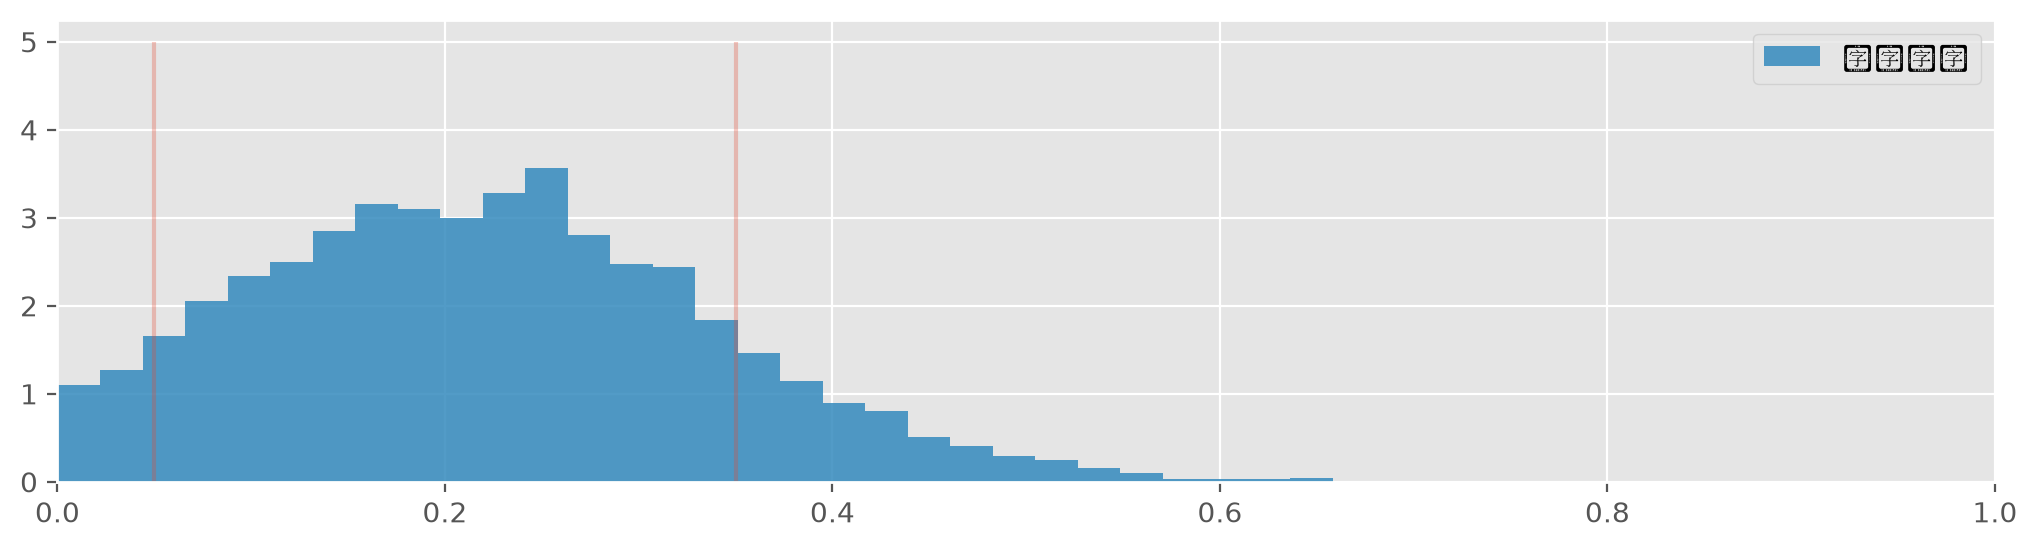

In [46]:

figsize(12.5, 3)
p_trace = np.concatenate(trace.posterior.freq_cheating.data[:, 15000:])  # burned_trace["freq_cheating"][15000:]
plt.hist(p_trace, histtype="stepfilled", density=True, alpha=0.85, bins=30,
         label="后验分布", color="#348ABD")
plt.vlines([.05, .35], [0, 0], [5, 5], alpha=0.3)
plt.xlim(0, 1)
plt.legend();



从上面这张图可以看出,我们对作弊者的真实比例仍然相当不确定,但已经把范围收窄到了 0.05 到 0.35 之间(用实线标出)。考虑到我们*先验地*完全不知道有多少学生可能作过弊(所以才用了均匀先验),这已经算是不错的结果了。但从另一个角度看,这也不算特别好,因为真实值很可能落在一个长度为 0.3 的区间内。那我们到底有没有学到什么东西,还是说我们对真实频率依然太不确定了?

我认为,是的,我们确实发现了一些东西。根据我们的后验分布,"完全没有人作弊"是不太可能的——也就是说,后验给 $p=0$ 分配了很低的概率。既然我们一开始用的是均匀先验,把 $p$ 的所有取值都同等看待,但数据排除掉了 $p=0$ 这个可能性,我们就可以比较有把握地说,确实存在作弊的学生。

这类算法可以用来从用户那里收集隐私信息,并有*相当的把握*相信这些数据虽然带有噪声,但整体是真实可信的。



### 另一种 PyMC 建模方式

如果给定 $p$ 的值(从我们"上帝视角"是已知的),我们可以求出学生回答"是"的概率:

\begin{align}
P(\text{"是"}) = & P( \text{第一次正面} )P( \text{作弊} ) + P( \text{第一次反面} )P( \text{第二次正面} ) \\\\
& = \frac{1}{2}p + \frac{1}{2}\frac{1}{2}\\\\
& = \frac{p}{2} + \frac{1}{4}
\end{align}

因此,知道了 $p$,我们就知道学生回答"是"的概率。在 PyMC 中,我们可以创建一个确定性函数,来计算给定 $p$ 时回答"是"的概率:


In [47]:

with pm.Model() as model:
    p = pm.Uniform("freq_cheating", 0, 1)
    p_skewed = pm.Deterministic("p_skewed", 0.5 * p + 0.25)



我本可以直接写成一行 `p_skewed = 0.5*p + 0.25`,因为加法和标量乘法这些基本操作会隐式地创建一个 `deterministic` 变量,但为了讲清楚原理,我把这个 `deterministic` 的模板代码显式地写了出来。

如果我们知道受访者回答"是"的概率(也就是 `p_skewed`),并且有 $N=100$ 名学生,那么"是"的回答数量就是一个参数为 `N` 和 `p_skewed` 的二项随机变量。

这里我们把观测到的 35 个"是"的回答纳入进来。在声明 `pm.Binomial` 时,我们加上 `observed=35`。


In [48]:

with model:
    yes_responses = pm.Binomial("number_cheaters", 100, p_skewed, observed=35)



下面我们把所有感兴趣的变量放进一个 `Model` 容器,并运行我们的"黑箱"算法。


In [49]:

with model:
    # 将在第三章解释!
    step = pm.Metropolis()
    # 新的 tune 参数意味着丢弃前 2500 个不稳定的样本
    trace = pm.sample(25000, step=step, tune=2500)
    # burned_trace = trace[2500:]


Multiprocess sampling (2 chains in 2 jobs)


Metropolis: [freq_cheating]


Output()

Sampling 2 chains for 2_500 tune and 25_000 draw iterations (5_000 + 50_000 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

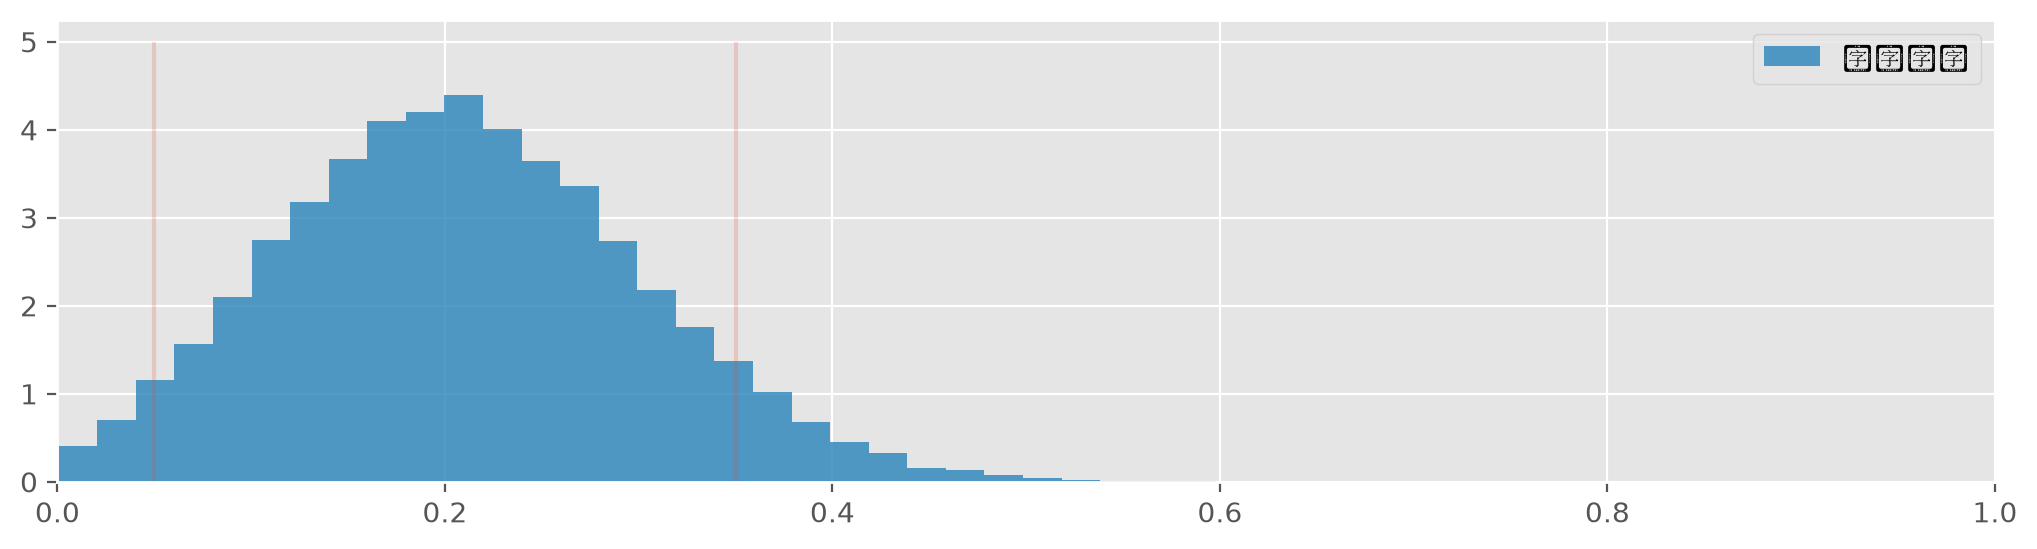

In [50]:

figsize(12.5, 3)
p_trace = np.concatenate(trace.posterior.freq_cheating.data[:, :])  # burned_trace["freq_cheating"]
plt.hist(p_trace, histtype="stepfilled", density=True, alpha=0.85, bins=30,
         label="后验分布", color="#348ABD")
plt.vlines([.05, .35], [0, 0], [5, 5], alpha=0.2)
plt.xlim(0, 1)
plt.legend();



### 更多 PyMC 小技巧

#### 小贴士:用数组存放 PyMC 变量

没有理由不能把多个不同类型的 PyMC 变量存放在一个 NumPy 数组里,只需要在初始化数组时记得把 `dtype` 设为 `object` 即可。例如:


In [51]:

N = 10
x = np.ones(N, dtype=object)
with pm.Model() as model:
    for i in range(0, N):
        x[i] = pm.Exponential('x_%i' % i, (i + 1.0) ** 2)



本章剩余的部分,会考察一些 PyMC 和 PyMC 建模的实际应用例子:



##### 示例: 挑战者号航天飞机灾难 <span id="challenger"/>

1986 年 1 月 28 日,美国航天飞机计划第 25 次发射任务以灾难告终:挑战者号航天飞机的一个助推火箭在升空后不久发生爆炸,机上七名机组人员全部遇难。总统事故调查委员会得出结论:事故原因是火箭助推器某个现场接头处的 O 型密封圈失效,而这一失效源于一处设计缺陷,使得 O 型圈对包括外部温度在内的多个因素异常敏感。此前的 24 次飞行中,有 23 次留有 O 型圈失效的数据(其中一次数据在海上遗失),这些数据本应在挑战者号发射前一晚被讨论,但遗憾的是,当时人们只关注了那 7 次真正发生过损伤事故的飞行数据,并且认为这些数据看不出明显趋势。数据如下所示(参见 [1]):


温度 (华氏度), O 型圈是否失效?
[[66.  0.]
 [70.  1.]
 [69.  0.]
 [68.  0.]
 [67.  0.]
 [72.  0.]
 [73.  0.]
 [70.  0.]
 [57.  1.]
 [63.  1.]
 [70.  1.]
 [78.  0.]
 [67.  0.]
 [53.  1.]
 [67.  0.]
 [75.  0.]
 [70.  0.]
 [81.  0.]
 [76.  0.]
 [79.  0.]
 [75.  1.]
 [76.  0.]
 [58.  1.]]


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21542 (\N{CJK UNIFIED IDEOGRAPH-5426}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

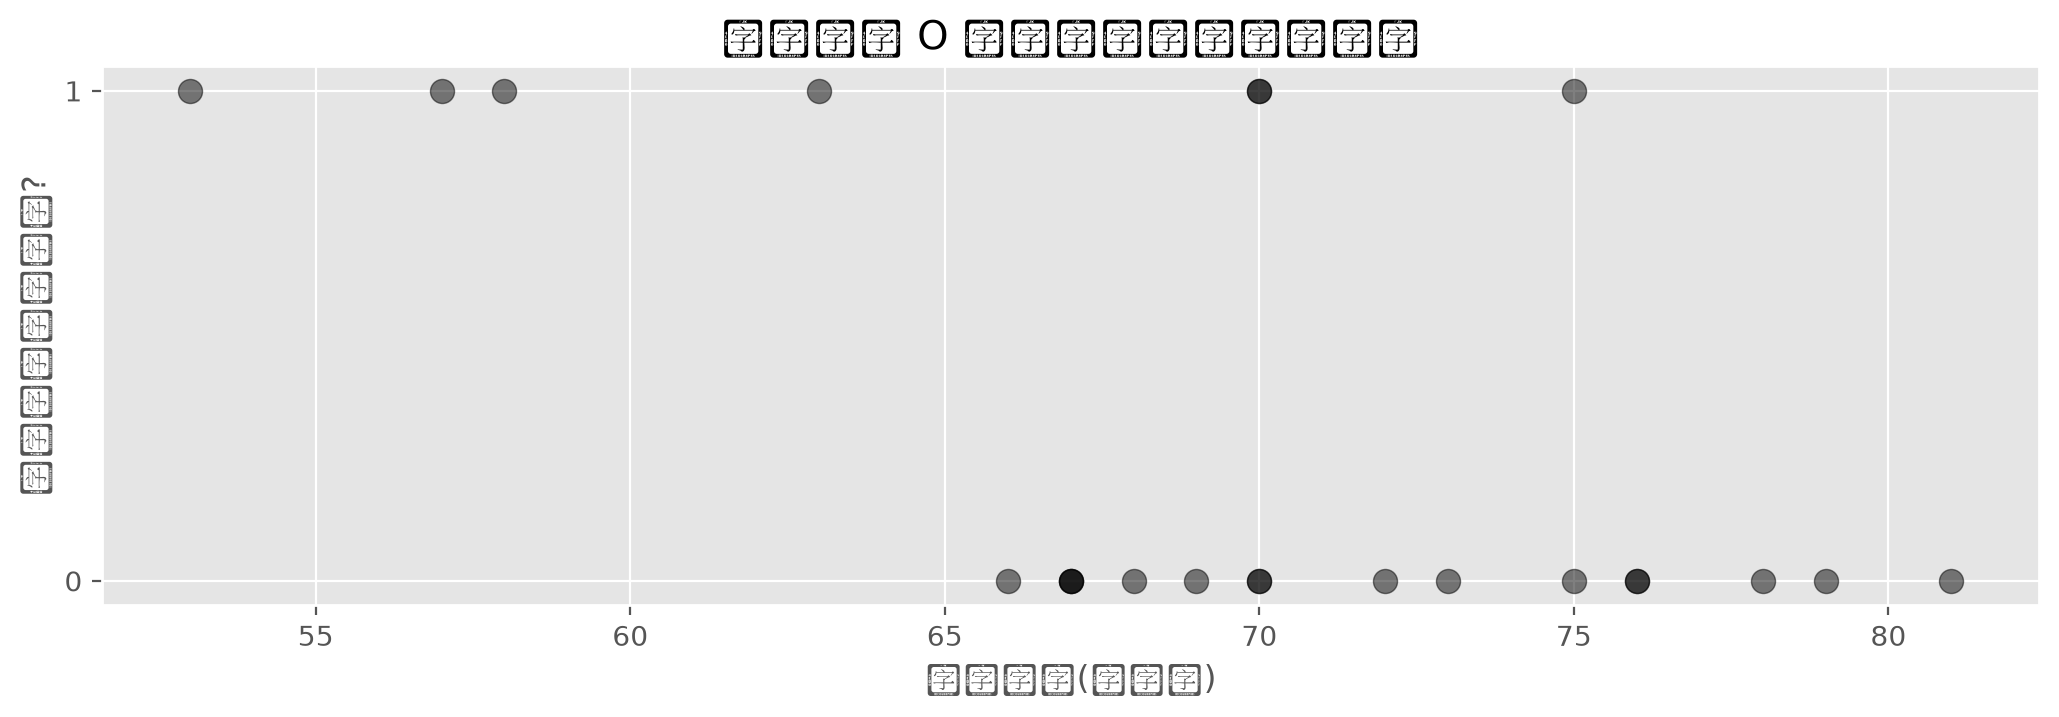

In [52]:

figsize(12.5, 3.5)
np.set_printoptions(precision=3, suppress=True)
challenger_data = np.genfromtxt("data/challenger_data.csv", skip_header=1,
                                 usecols=[1, 2], missing_values="NA",
                                 delimiter=",")
# 丢弃缺失值(NA)
challenger_data = challenger_data[~np.isnan(challenger_data[:, 1])]

# 以温度(第一列)为横轴画出数据
print("温度 (华氏度), O 型圈是否失效?")
print(challenger_data)

plt.scatter(challenger_data[:, 0], challenger_data[:, 1], s=75, color="k",
            alpha=0.5)
plt.yticks([0, 1])
plt.ylabel("是否发生损伤事故?")
plt.xlabel("外部温度(华氏度)")
plt.title("航天飞机 O 型圈缺陷与温度的关系");



可以清楚地看出,随着外部温度降低,发生损伤事故的*概率*似乎在上升。我们之所以关心对"概率"建模,是因为温度和损伤事故之间似乎并不存在一个严格的分界点。我们能做的最好的事,就是去问:"在温度 $t$ 下,发生损伤事故的概率是多少?"这个例子的目标,就是要回答这个问题。

我们需要一个关于温度的函数,记作 $p(t)$,它的取值要限制在 0 到 1 之间(这样才能表示一个概率),并且随着温度升高,从 1 逐渐变化到 0。满足这样条件的函数其实有很多,但最常用的选择是*逻辑斯蒂函数*(logistic function)。

$$p(t) = \frac{1}{ 1 + e^{ \;\beta t } } $$

在这个模型里,$\beta$ 是我们不确定的变量。下面画出了 $\beta = 1, 3, -5$ 时对应的函数图像。


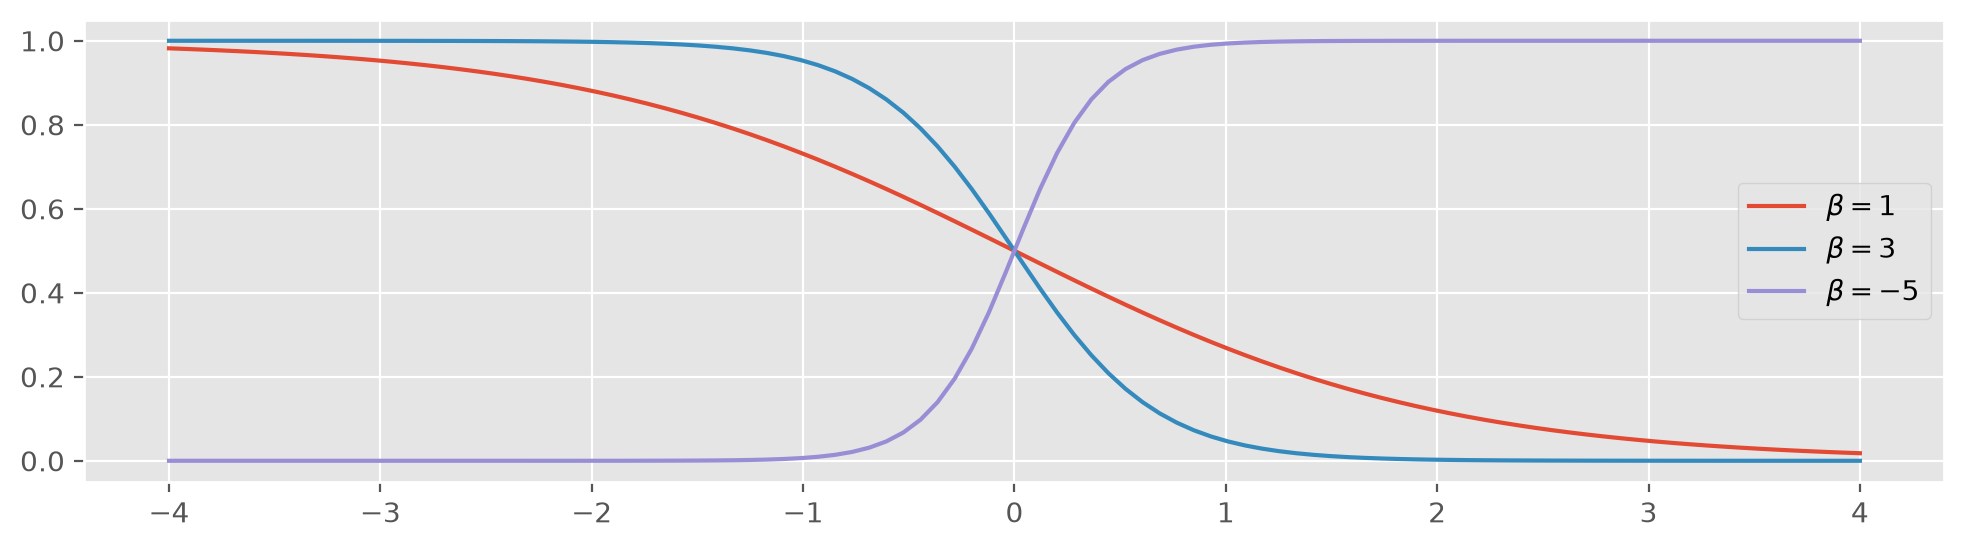

In [53]:

figsize(12, 3)

def logistic(x, beta):
    return 1.0 / (1.0 + np.exp(beta * x))

x = np.linspace(-4, 4, 100)
plt.plot(x, logistic(x, 1), label=r"$\beta = 1$")
plt.plot(x, logistic(x, 3), label=r"$\beta = 3$")
plt.plot(x, logistic(x, -5), label=r"$\beta = -5$")
plt.legend();



但似乎还缺了点什么。在上面这张逻辑斯蒂函数的图里,概率只在 0 附近发生明显变化,但我们的数据里,概率变化发生在 65 到 70 附近。我们需要给逻辑斯蒂函数加上一个*偏置*项:

$$p(t) = \frac{1}{ 1 + e^{ \;\beta t + \alpha } } $$

下面是几种不同 $\alpha$ 取值下的图像。


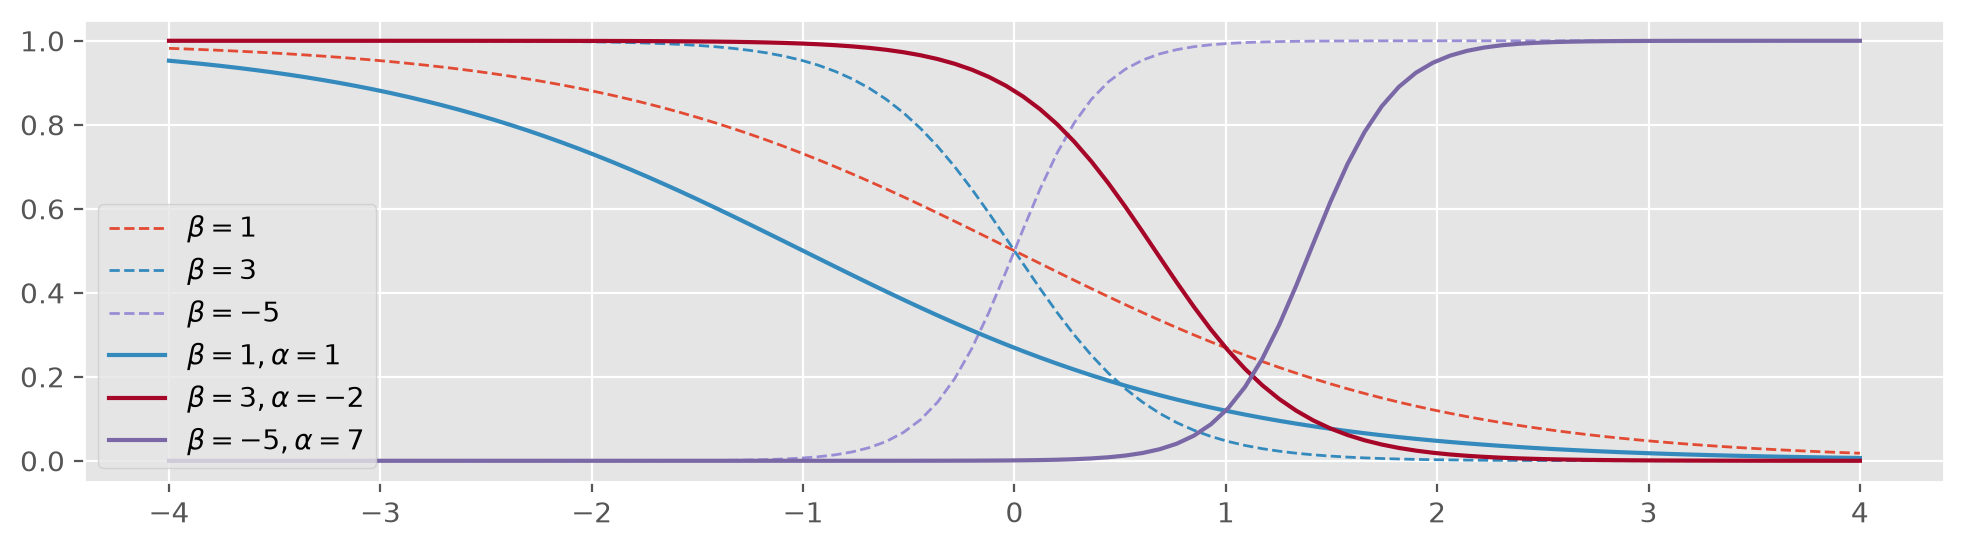

In [54]:

def logistic(x, beta, alpha=0):
    return 1.0 / (1.0 + np.exp(np.dot(beta, x) + alpha))

x = np.linspace(-4, 4, 100)

plt.plot(x, logistic(x, 1), label=r"$\beta = 1$", ls="--", lw=1)
plt.plot(x, logistic(x, 3), label=r"$\beta = 3$", ls="--", lw=1)
plt.plot(x, logistic(x, -5), label=r"$\beta = -5$", ls="--", lw=1)

plt.plot(x, logistic(x, 1, 1), label=r"$\beta = 1, \alpha = 1$",
         color="#348ABD")
plt.plot(x, logistic(x, 3, -2), label=r"$\beta = 3, \alpha = -2$",
         color="#A60628")
plt.plot(x, logistic(x, -5, 7), label=r"$\beta = -5, \alpha = 7$",
         color="#7A68A6")

plt.legend(loc="lower left");



加上一个常数项 $\alpha$,相当于把曲线向左或向右平移(这也是它被称为*偏置*的原因)。

让我们开始用 PyMC 为它建模。$\beta, \alpha$ 这两个参数没有理由必须是正数、有界或者数值很大,所以最适合用*正态随机变量*为它们建模,我们接下来就会介绍正态分布。



### 正态分布

一个正态随机变量,记作 $X \sim N(\mu, 1/\tau)$,它的分布由两个参数决定:均值 $\mu$,以及*精度*(precision)$\tau$。熟悉正态分布的读者可能更常见到的是 $\sigma^2$ 而不是 $\tau^{-1}$,事实上二者互为倒数。这个改动的动机是为了让数学分析更简单,是早期贝叶斯方法遗留下来的一个习惯。只需要记住:$\tau$ 越小,分布越"分散"(也就是我们越不确定);$\tau$ 越大,分布越"集中"(也就是我们越确定)。不管怎样,$\tau$ 始终是正数。

$N(\mu, 1/\tau)$ 随机变量的概率密度函数是:

$$ f(x | \mu, \tau) = \sqrt{\frac{\tau}{2\pi}} \exp\left( -\frac{\tau}{2} (x-\mu)^2 \right) $$

下面我们画出几条不同的密度函数曲线。


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2882299/4004250419.py:12: SyntaxWarning: invalid escape sequence '\m'
  label="$\mu = %d,\;\\tau = %.1f$" % (_mu, _tau), color=_color)
Font 'default' does not have a glyph for '\u5728' [U+5728], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5904' [U+5904], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bc6' [U+5bc6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5ea6' [U+5ea6], substituting with a dummy symbol.


...

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

Font 'default' does not have a glyph for '\u5904' [U+5904], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5bc6' [U+5bc6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5ea6' [U+5ea6], substituting with a dummy symbol.


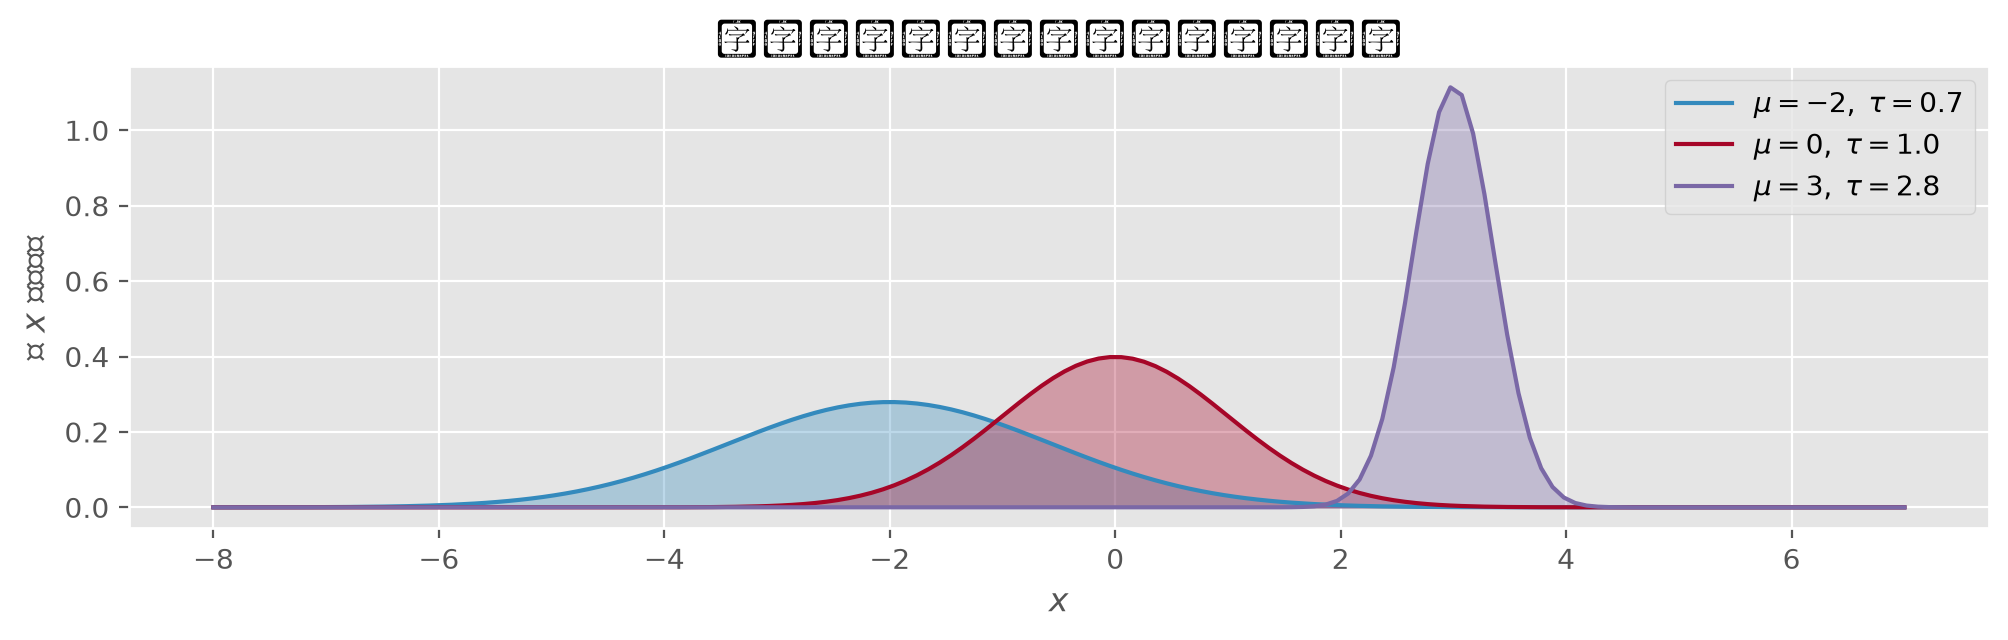

In [55]:

import scipy.stats as stats

nor = stats.norm
x = np.linspace(-8, 7, 150)
mu = (-2, 0, 3)
tau = (.7, 1, 2.8)
colors = ["#348ABD", "#A60628", "#7A68A6"]
parameters = zip(mu, tau, colors)

for _mu, _tau, _color in parameters:
    plt.plot(x, nor.pdf(x, _mu, scale=1. / _tau),
             label="$\mu = %d,\;\\tau = %.1f$" % (_mu, _tau), color=_color)
    plt.fill_between(x, nor.pdf(x, _mu, scale=1. / _tau), color=_color,
                      alpha=.33)

plt.legend(loc="upper right")
plt.xlabel("$x$")
plt.ylabel("在 $x$ 处的密度")
plt.title("三个不同正态随机变量的概率分布");



正态随机变量可以取任意实数,但它的取值大概率会相对靠近 $\mu$。事实上,正态分布的期望值恰好等于它的 $\mu$ 参数:

$$ E[ X | \mu, \tau] = \mu$$

它的方差等于 $\tau$ 的倒数:

$$Var( X | \mu, \tau ) = \frac{1}{\tau}$$

下面我们继续为挑战者号航天飞机的例子建模:


In [56]:

import pymc as pm

temperature = challenger_data[:, 0]
D = challenger_data[:, 1]  # 是否发生缺陷?

# 注意这里的 `initval`。我们下面会解释原因。
with pm.Model() as model:
    beta = pm.Normal("beta", mu=0, tau=0.001, initval=0)
    alpha = pm.Normal("alpha", mu=0, tau=0.001, initval=0)
    p = pm.Deterministic("p", 1.0 / (1. + at.exp(beta * temperature + alpha)))



我们已经有了概率,但要怎么把它和观测数据关联起来呢?一个参数为 $p$ 的*伯努利*随机变量,记作 $\text{Ber}(p)$,以概率 $p$ 取值 1,否则取值 0。因此我们的模型可以写成:

$$ \text{损伤事故 } D_i \sim \text{Ber}( \;p(t_i)\; ), \;\; i=1..N$$

其中 $p(t)$ 就是我们的逻辑斯蒂函数,$t_i$ 是我们观测数据对应的温度。注意在上面的代码中,我们把 `beta` 和 `alpha` 的初始值都设成了 0。原因在于,如果 `beta` 和 `alpha` 取值很大,会让 `p` 恰好等于 1 或者 0。不幸的是,`pm.Bernoulli` 不喜欢恰好为 0 或 1 的概率,尽管从数学上讲这些概率都是良好定义的。所以我们把系数的初始值设为 `0`,让变量 `p` 有一个比较合理的起始点。这不会影响我们的最终结果,也不意味着我们在先验中额外加入了什么信息,这只是 PyMC 在计算上的一个小注意事项。


In [57]:

# 通过一个伯努利随机变量, 把 `p` 里的概率和我们的观测数据关联起来。
with model:
    observed = pm.Bernoulli("bernoulli_obs", p, observed=D)

    # 神秘代码, 将在第三章解释
    start = pm.find_MAP()
    step = pm.Metropolis()
    trace = pm.sample(120000, step=step, initvals=start)
    # burned_trace = trace[100000::2]


Output()

Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>Metropolis: [beta]


>Metropolis: [alpha]


Output()

Sampling 2 chains for 1_000 tune and 120_000 draw iterations (2_000 + 240_000 draws total) took 88 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



我们已经用观测数据训练好了模型,现在可以从后验分布中采样了。让我们看看 $\alpha$ 和 $\beta$ 的后验分布:


Font 'default' does not have a glyph for '\u53d8' [U+53d8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u91cf' [U+91cf], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


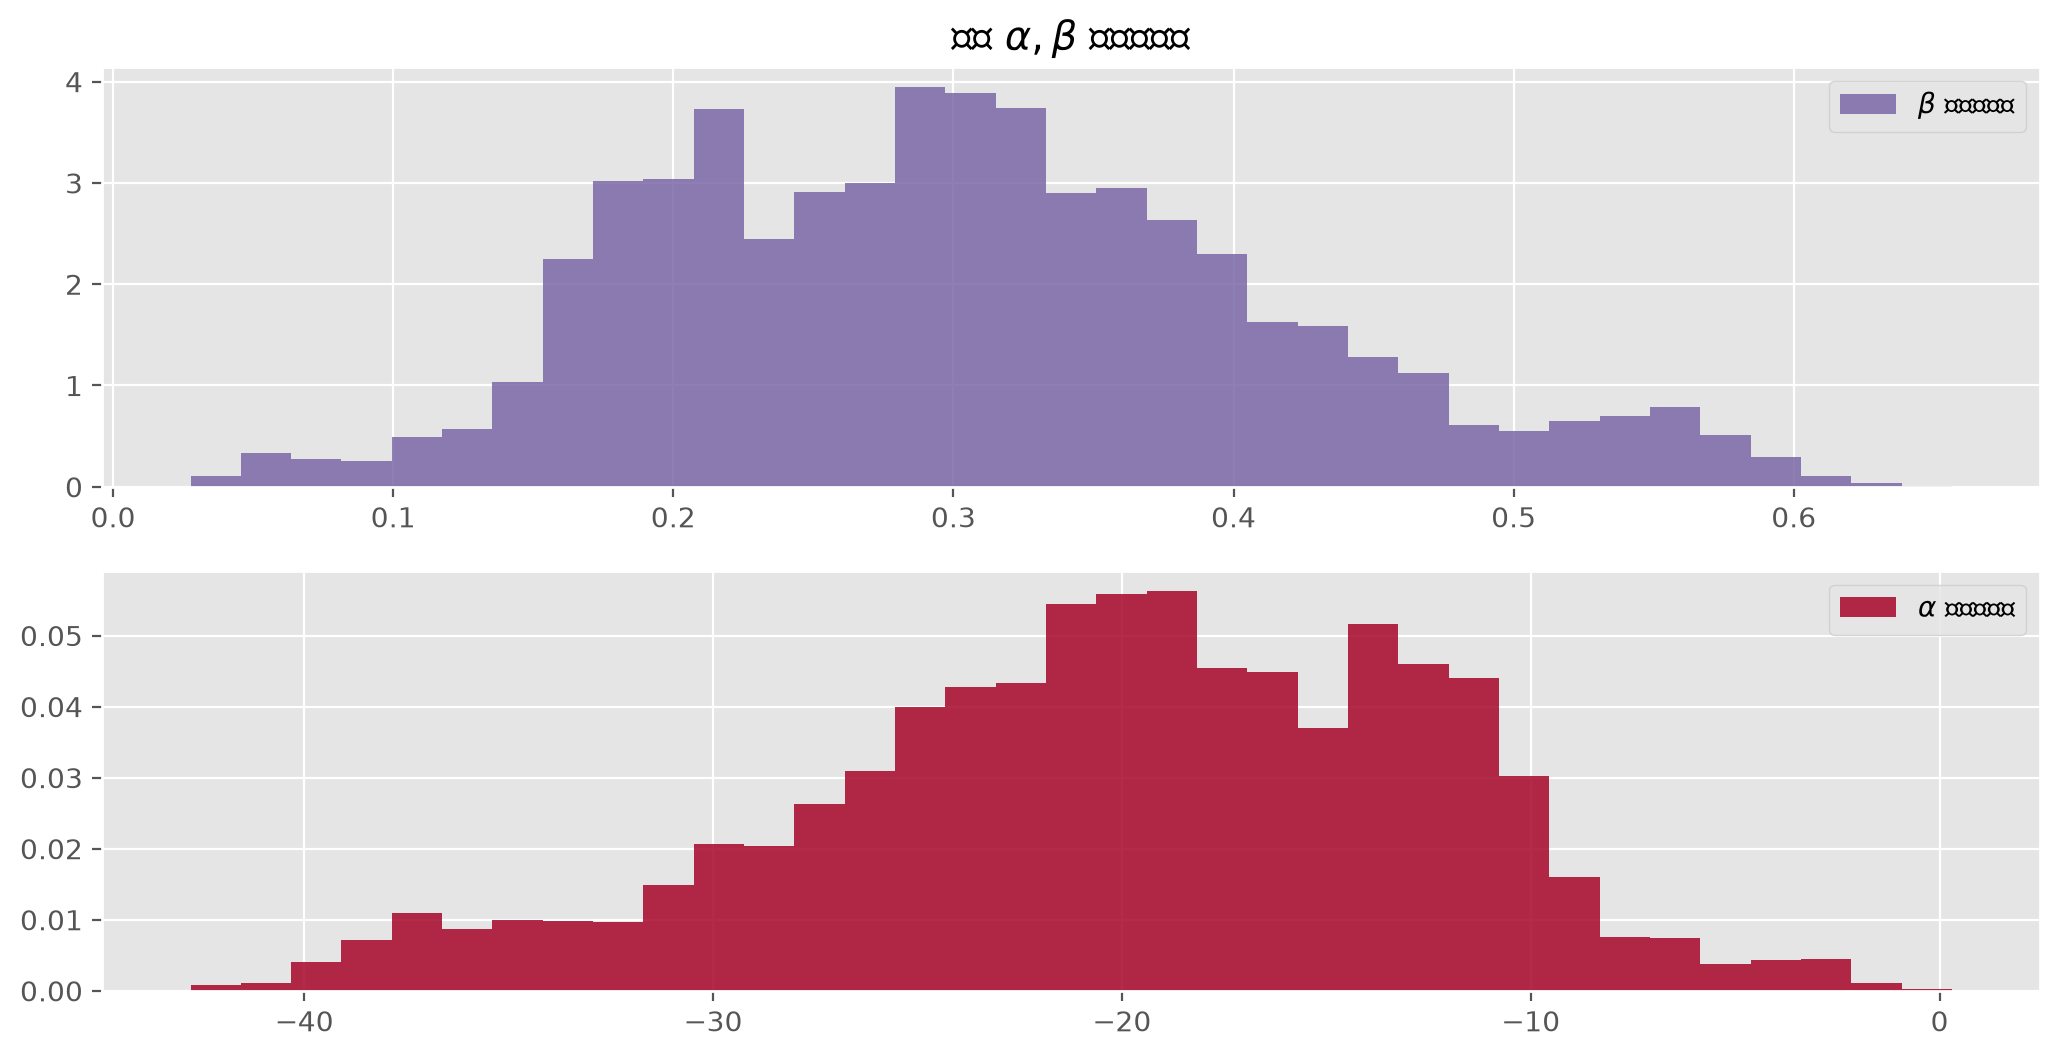

In [58]:

alpha_samples = np.concatenate(trace.posterior.alpha.data[:, 100000::2])[:, None]  # 最好把它们变成一维的
beta_samples = np.concatenate(trace.posterior.beta.data[:, 100000::2])[:, None]

figsize(12.5, 6)

# 样本的直方图:
plt.subplot(211)
plt.title(r"变量 $\alpha, \beta$ 的后验分布")
plt.hist(beta_samples, histtype='stepfilled', bins=35, alpha=0.85,
         label=r"$\beta$ 的后验分布", color="#7A68A6", density=True)
plt.legend()

plt.subplot(212)
plt.hist(alpha_samples, histtype='stepfilled', bins=35, alpha=0.85,
         label=r"$\alpha$ 的后验分布", color="#A60628", density=True)
plt.legend();


[]

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


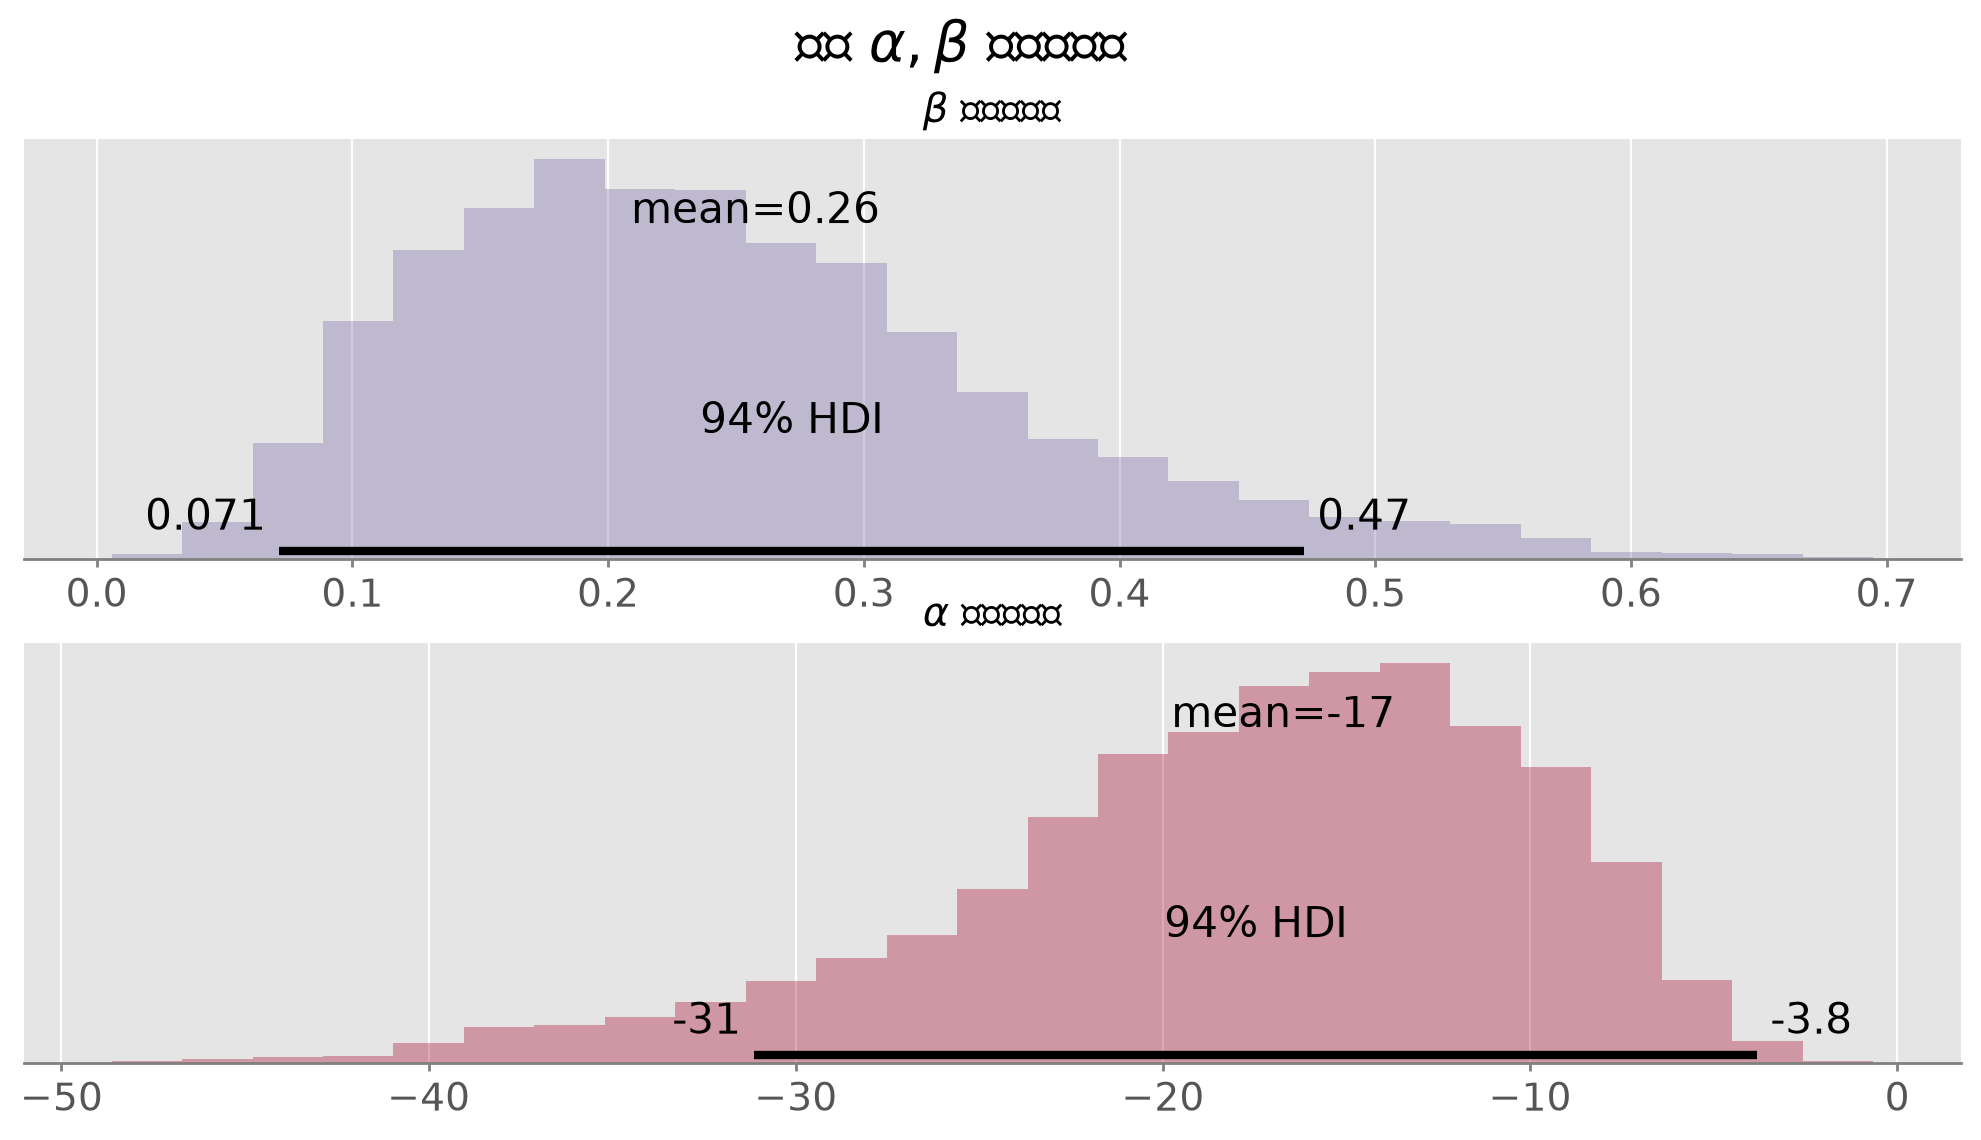

In [59]:

# 下面是 ArviZ 版本
figure, ax = plt.subplots(2, 1)

az.plot_posterior(trace, var_names=['beta'], kind='hist', bins=25,
                   figsize=(12.5, 6), color="#7A68A6", ax=ax[0])
az.plot_posterior(trace, var_names=['alpha'], kind='hist', bins=25,
                   figsize=(12.5, 6), color="#A60628", ax=ax[1])
plt.suptitle(r"变量 $\alpha, \beta$ 的后验分布", fontsize=20)
ax[0].set_title(r"$\beta$ 的后验分布")
ax[1].set_title(r"$\alpha$ 的后验分布")
plt.plot()



$\beta$ 的所有样本都大于 0。如果后验反而是围绕 0 分布的,我们可能会怀疑 $\beta = 0$,也就是说温度对缺陷概率没有影响。

类似地,$\alpha$ 的后验取值全部为负,并且明显远离 0,这说明我们有理由相信 $\alpha$ 显著小于 0。

从数据的分散程度来看,我们对真实参数究竟是多少仍然相当不确定(不过考虑到样本量较小、且缺陷与非缺陷数据之间有较大重叠,这种情况其实也在预料之中)。

接下来,让我们看看在某个特定温度下,*期望的概率*是多少。也就是说,我们对后验的所有样本取平均,得到 $p(t_i)$ 的一个可能取值。


In [60]:

t = np.linspace(temperature.min() - 5, temperature.max() + 5, 50)[:, None]
p_t = logistic(t.T, beta_samples, alpha_samples)

mean_prob_t = p_t.mean(axis=0)


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 38519 (\N{CJK UNIFIED IDEOGRAPH-9677}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


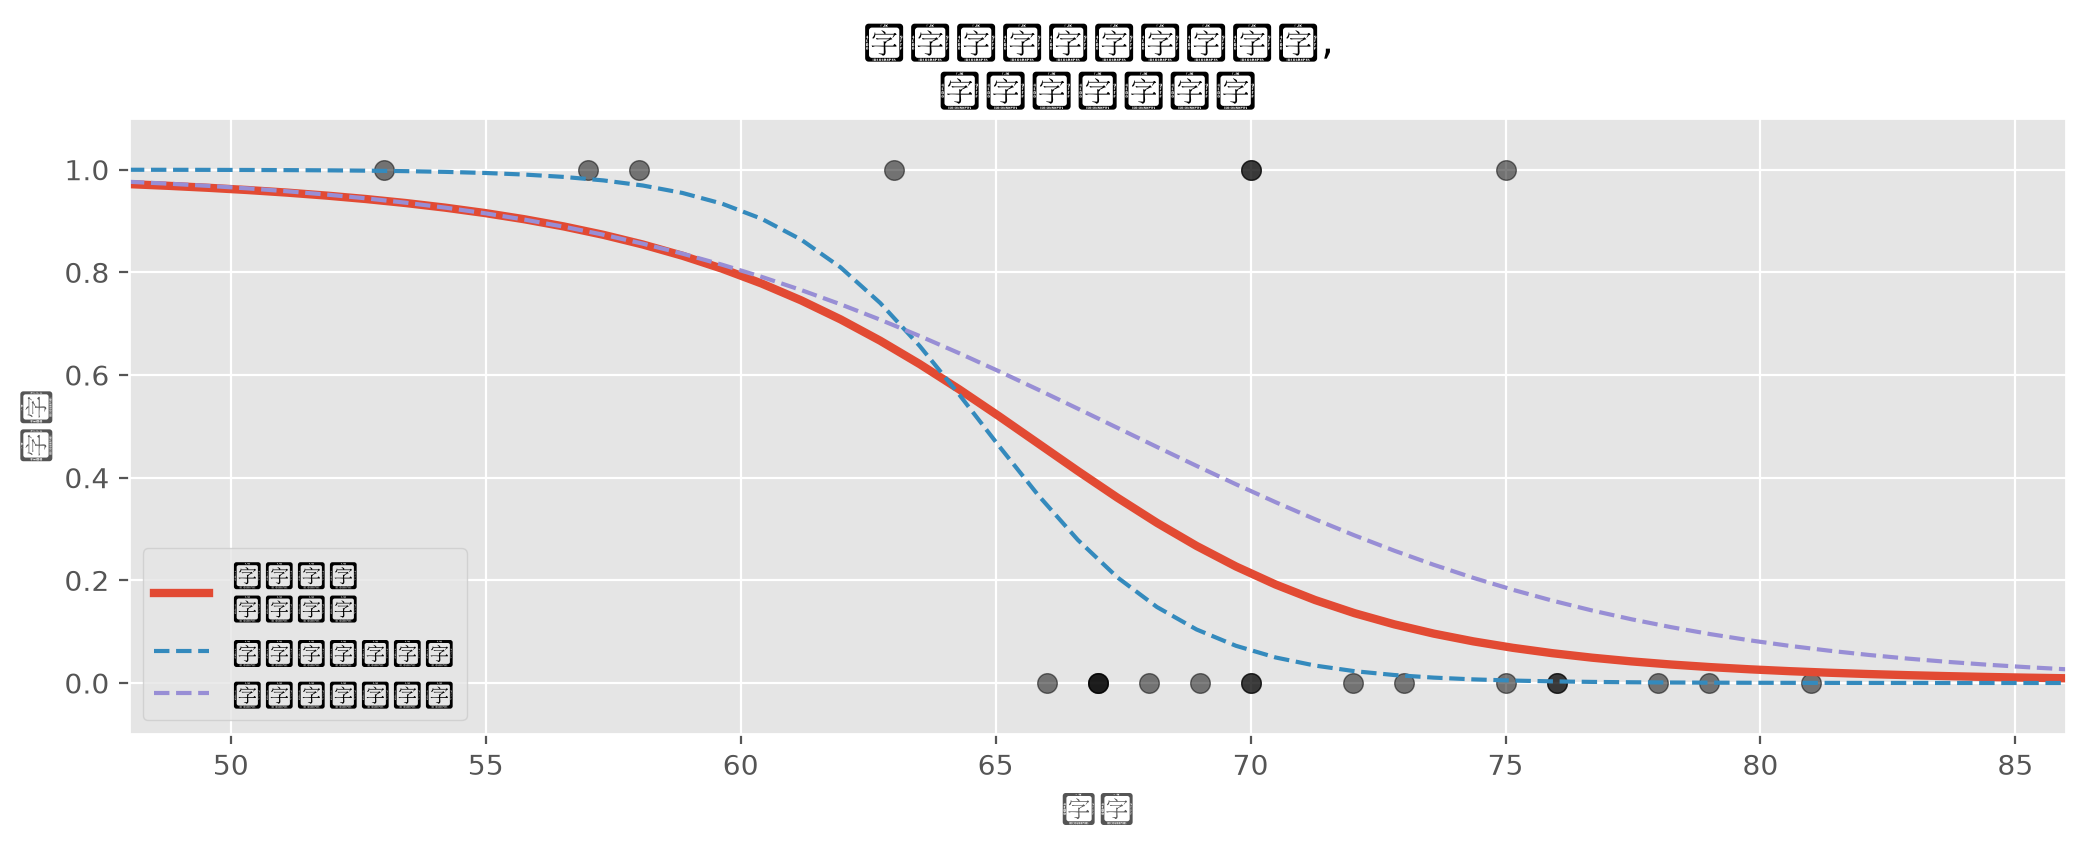

In [61]:

figsize(12.5, 4)

plt.plot(t, mean_prob_t, lw=3, label="后验平均\n缺陷概率")
plt.plot(t, p_t[0, :], ls="--", label="后验的一次实现")
plt.plot(t, p_t[-2, :], ls="--", label="后验的一次实现")
plt.scatter(temperature, D, color="k", s=50, alpha=0.5)
plt.title("缺陷概率的后验期望值,\n以及若干次实现")
plt.legend(loc="lower left")
plt.ylim(-0.1, 1.1)
plt.xlim(t.min(), t.max())
plt.ylabel("概率")
plt.xlabel("温度");



上图中我们还画出了两条实际系统可能的实现曲线。它们和其他任何一条抽样曲线一样"合理"。蓝色实线是把所有 20000 条可能的虚线平均之后得到的结果。

一个有意思的问题是:在哪些温度下,我们对缺陷概率最不确定?下面我们画出期望值曲线,**并**给出每个温度对应的 95% 区间。


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
Font 'default' does not have a glyph for '\u7ed9' [U+7ed9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5b9a' [U+5b9a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6e29' [U+6e29], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5ea6' [U+5ea6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u65f6' [U+65f6], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4f30' [U+4f30], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u8ba1' [U+8ba1], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6e29' [U+6e29], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5ea6' [U+5ea6], substituting with a dummy symbol.


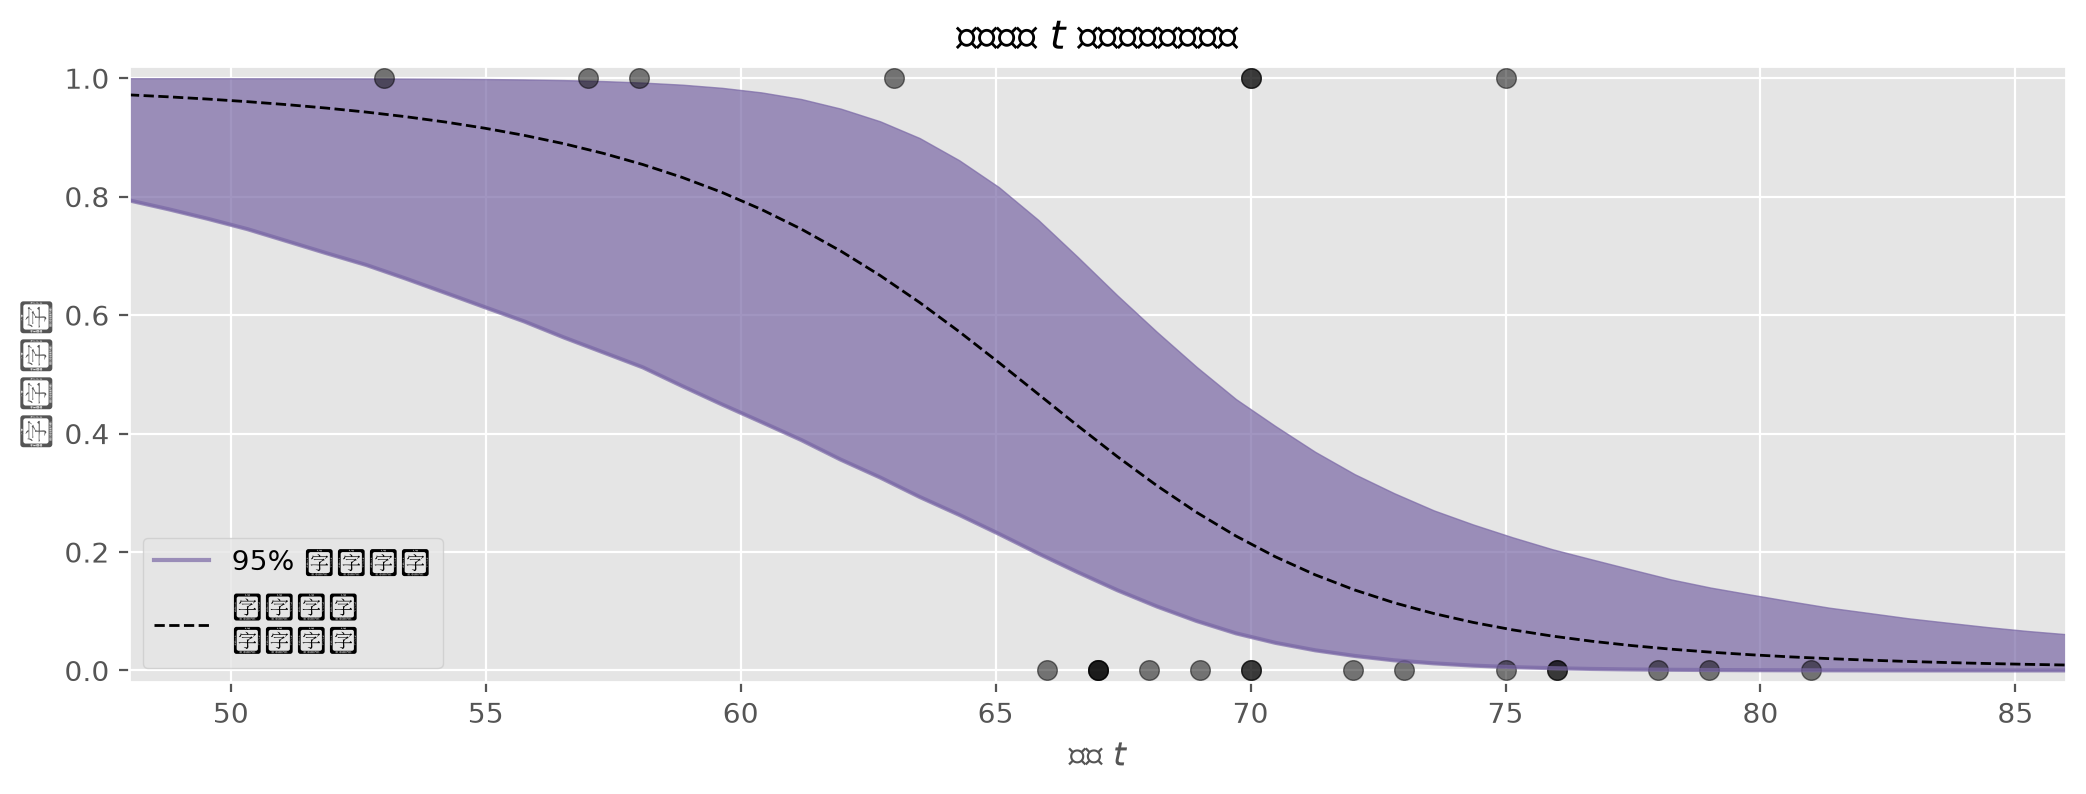

In [62]:

from scipy.stats.mstats import mquantiles

# 向量化计算 2.5% 和 97.5% 分位数, 作为 "置信区间"
qs = mquantiles(p_t, [0.025, 0.975], axis=0)
plt.fill_between(t[:, 0], *qs, alpha=0.7,
                  color="#7A68A6")

plt.plot(t[:, 0], qs[0], label="95% 可信区间", color="#7A68A6", alpha=0.7)

plt.plot(t, mean_prob_t, lw=1, ls="--", color="k",
         label="后验平均\n缺陷概率")

plt.xlim(t.min(), t.max())
plt.ylim(-0.02, 1.02)
plt.legend(loc="lower left")
plt.scatter(temperature, D, color="k", s=50, alpha=0.5)
plt.xlabel("温度 $t$")

plt.ylabel("概率估计")
plt.title("给定温度 $t$ 时的后验概率估计");



图中用紫色画出的*95% 可信区间*(95% CI),表示对每个温度而言,包含了 95% 分布质量的那段区间。例如,在 65 度时,我们有 95% 的把握认为缺陷概率落在 0.25 到 0.75 之间。

更一般地说,可以看到,当温度接近 60 度时,可信区间会迅速在 $[0,1]$ 上铺开;而一旦超过 70 度,区间又重新收紧。这能给我们提供一些下一步该怎么做的线索:我们大概应该在 60-65 度这个温度区间多测试一些 O 型圈,以便更好地估计这个区间内的概率。同理,在向科学家汇报估计结果时,应当格外谨慎,不要只是简单地告诉他们期望概率是多少,因为这并不能反映出后验分布究竟有*多宽*。



### 挑战者号失事当天的情况呢?

挑战者号失事当天,外部温度是华氏 31 度。在这个温度下,发生缺陷的后验概率分布是什么样的?下面画出了这个分布。可以看出,挑战者号几乎注定会遭遇 O 型圈缺陷问题。


Font 'default' does not have a glyph for '\u65f6' [U+65f6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7f3a' [U+7f3a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9677' [U+9677], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6982' [U+6982], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u540e' [U+540e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9a8c' [U+9a8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5e03' [U+5e03], substituting with a dummy symbol.


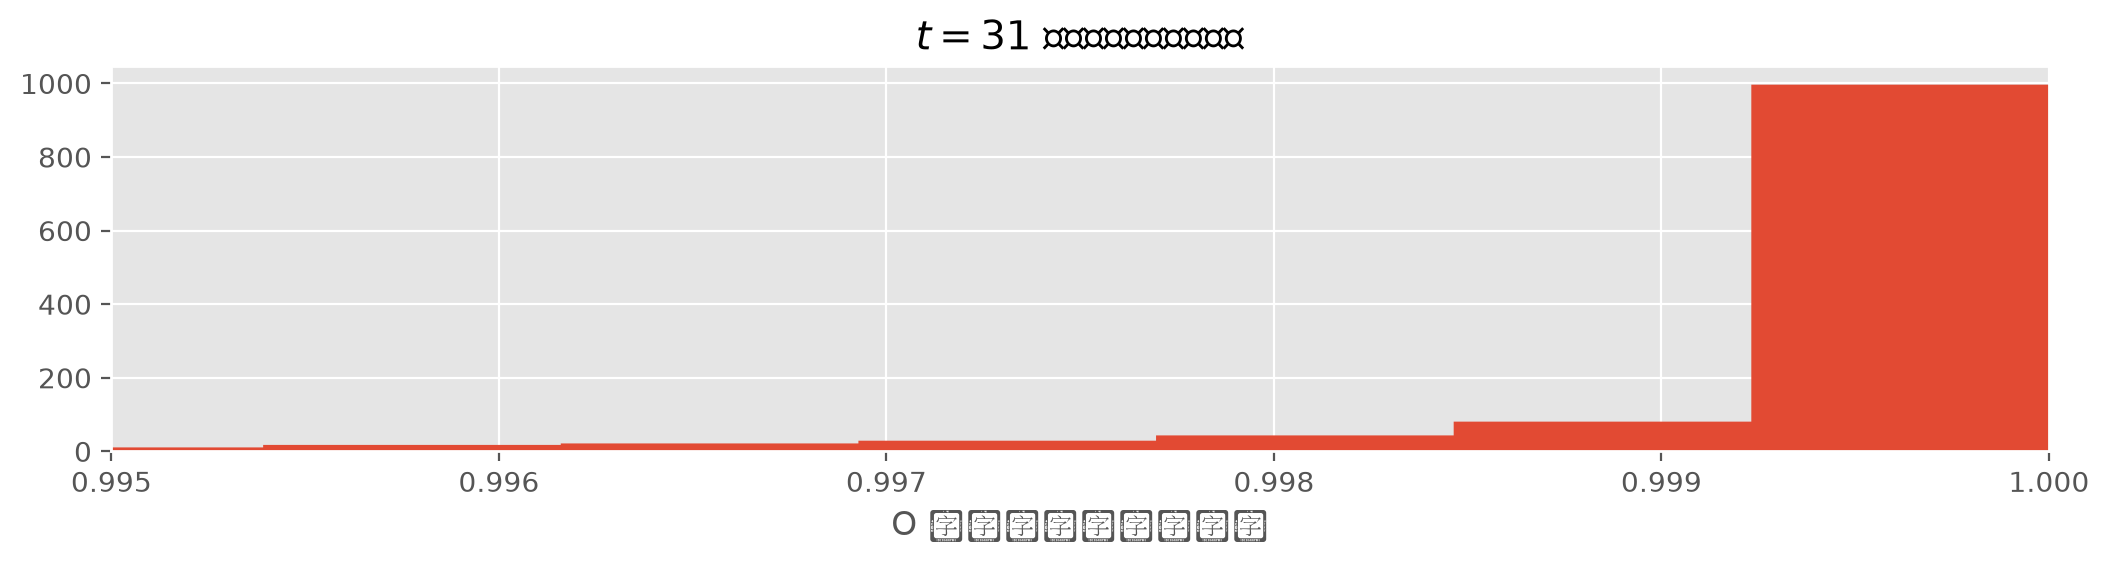

In [63]:

figsize(12.5, 2.5)

prob_31 = logistic(31, beta_samples, alpha_samples)

plt.xlim(0.995, 1)
plt.hist(prob_31, bins=1000, density=True, histtype='stepfilled')
plt.title("$t = 31$ 时缺陷概率的后验分布")
plt.xlabel("O 型圈发生缺陷的概率");



### 我们的模型合适吗?

有怀疑精神的读者可能会说:"你刻意为 $p(t)$ 选择了逻辑斯蒂函数,还选择了特定的先验。换成别的函数或先验,或许会得到不同的结果。我怎么知道自己选的是一个好模型?"这个质疑完全合理。考虑一个极端情形:如果我选择的函数是 $p(t) = 1,\; \forall t$,意味着缺陷必然发生,我同样会预测 1 月 28 日会发生灾难。但这显然是一个选得很糟糕的模型。另一方面,如果我确实选择了逻辑斯蒂函数作为 $p(t)$,但把所有先验都设得非常紧、紧紧围绕在 0 附近,我们很可能会得到截然不同的后验分布。我们怎么知道自己的模型真的是数据的一种恰当表达?这促使我们去衡量模型的**拟合优度**(goodness of fit)。

我们可以这样想:*要怎么检验模型拟合得不好?*一个想法是,把观测数据(回忆一下,它是一个*固定的*随机变量)和我们可以模拟出的人工数据集进行比较。这个思路的原理是:如果模拟出的数据集在统计意义上看起来和观测数据集不像,那么我们的模型很可能没能准确地刻画出观测数据。

本章前面,我们为短信例子模拟过人工数据集。当时,我们是从先验中采样得到的数值。我们看到生成出来的数据集千差万别,很少能真正模仿观测数据集。而在当前这个例子里,我们应该从*后验*分布中采样,来生成*非常合理*的数据集。幸运的是,我们的贝叶斯框架让这件事变得非常简单。我们只需要创建一个新的 `Stochastic` 变量,它和存放观测数据的那个变量完全一样,只是不再传入观测值本身。回忆一下,我们存放观测数据的那个 `Stochastic` 变量是:

    observed = pm.Bernoulli("bernoulli_obs", p, observed=D)

于是我们创建:

    simulated_data = pm.Bernoulli("simulation_data", p)

让我们模拟 10000 次:


In [64]:

N = 10000

with pm.Model() as model:
    beta = pm.Normal("beta", mu=0, tau=0.001)
    alpha = pm.Normal("alpha", mu=0, tau=0.001)
    p = pm.Deterministic("p", 1.0 / (1. + at.exp(beta * temperature + alpha)))
    observed = pm.Bernoulli("bernoulli_obs", p, observed=D)

    simulated = pm.Bernoulli("bernoulli_sim", p, shape=p.shape)
    step = pm.Metropolis()
    trace = pm.sample(N, step=step)


Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>Metropolis: [beta]


>Metropolis: [alpha]


>Metropolis: [bernoulli_sim]


Output()

Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 25 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


(10000, 23)


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

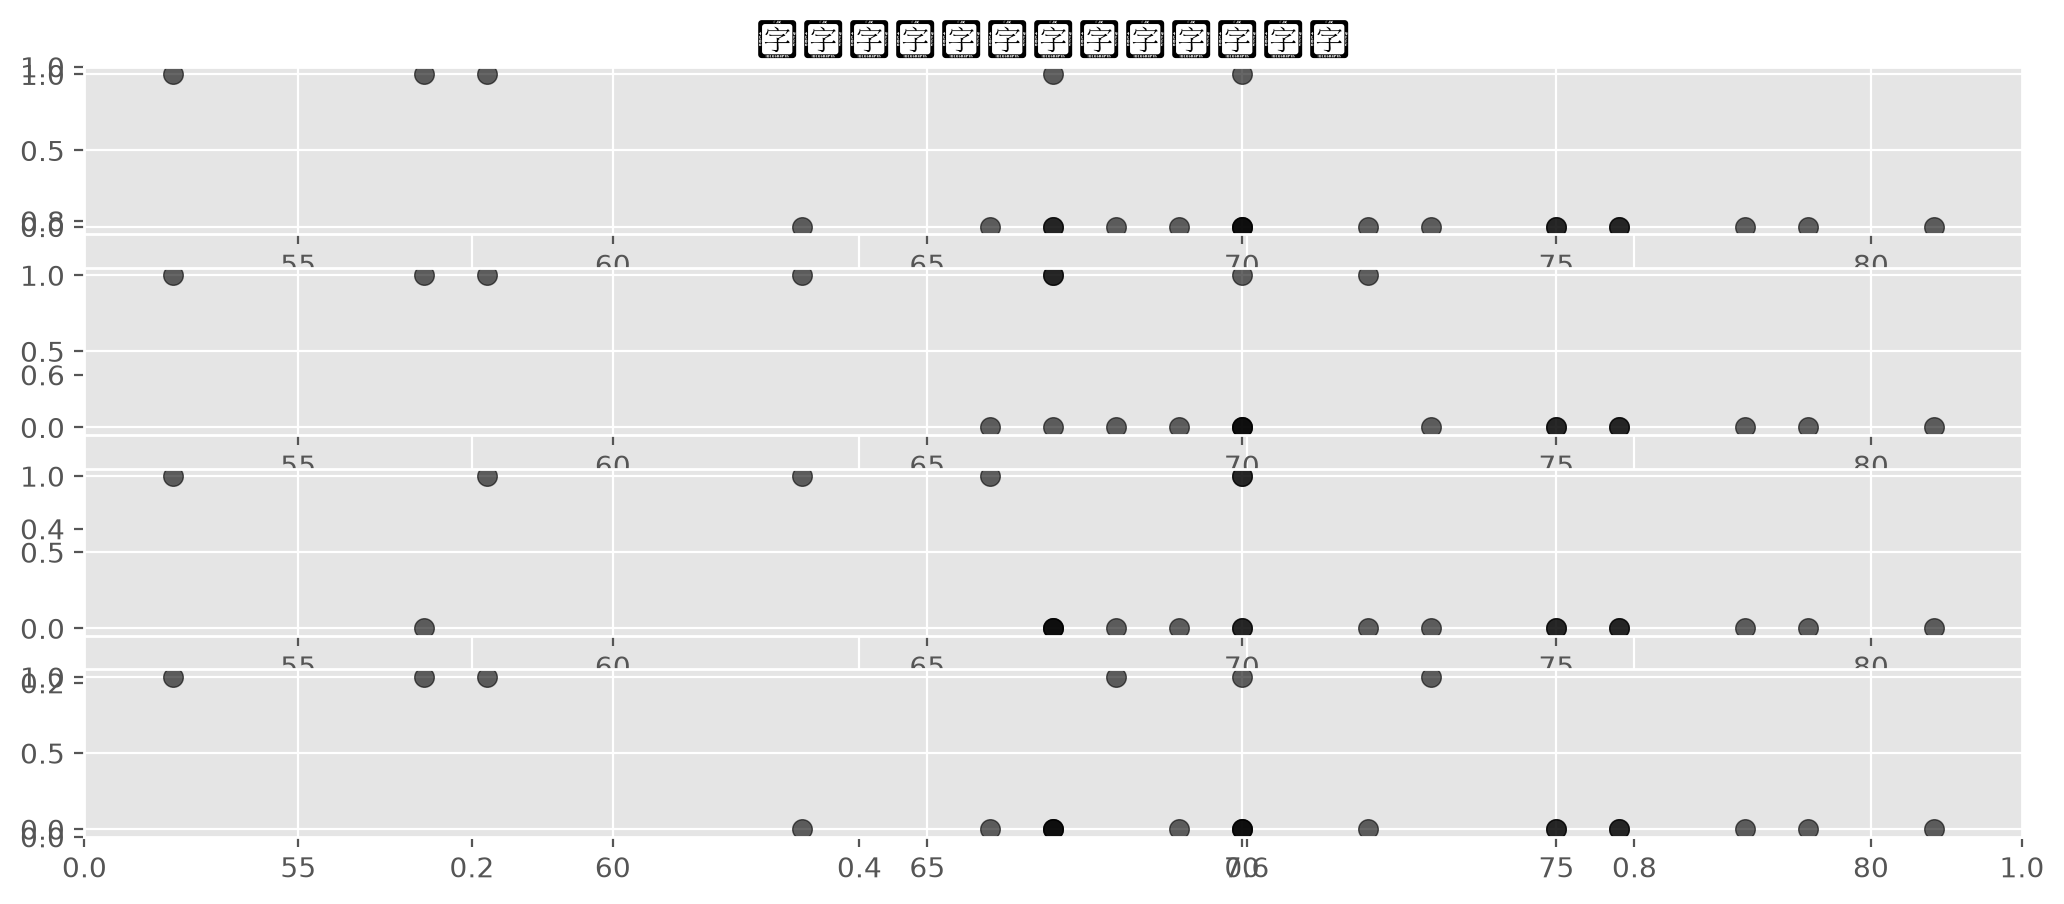

In [65]:

figsize(12.5, 5)
plt.style.use("ggplot")
simulations = trace.posterior.bernoulli_sim.data[1]
print(simulations.shape)

plt.title("用后验参数生成的模拟数据集")
figsize(12.5, 6)
for i in range(4):
    ax = plt.subplot(4, 1, i + 1)
    plt.scatter(temperature, simulations[1000 * i, :], color="k",
                s=50, alpha=0.6)



注意上面几张图各不相同(如果你能想到更清晰的展示方式,欢迎提交 pull request,也欢迎在[这里](http://stats.stackexchange.com/questions/53078/how-to-visualize-bayesian-goodness-of-fit-for-logistic-regression)回答!)。

我们希望评估自己的模型到底有多好。"好"当然是个主观的词,所以结果必须相对于其他模型来谈。

我们同样会用图形化的方式来做这件事,这看起来可能显得更不客观。另一种选择是使用*贝叶斯 p 值*,但它们同样是主观的,因为"好"与"坏"之间恰当的分界线本身就是任意设定的。Gelman 强调,图形化检验比 p 值检验更有启发性 [7]。我们也认同这一点。

下面这种图形化检验方法,是逻辑回归领域一种新颖的数据可视化手段,叫做*分离图*(separation plot)[8]。对于我们想要比较的一组模型,每个模型都会被画在各自的分离图上。分离图的技术细节我留给非常易读的[原始论文](https://onlinelibrary.wiley.com/doi/10.1111/j.1540-5907.2011.00525.x)去介绍,这里只总结一下它的用法。

对每个模型,我们计算后验模拟在某个特定温度下,提议出取值为 1 的比例,也就是通过取平均来计算 $P( \;\text{缺陷} = 1 | t, \alpha, \beta )$。这就给出了数据集中每个数据点上,发生缺陷的后验概率。例如,对我们上面用的模型:


In [66]:

posterior_probability = simulations.mean(axis=0)
print("缺陷的后验概率 | 实际是否发生缺陷 ")
for i in range(len(D)):
    print("%.2f                     |   %d" % (posterior_probability[i], D[i]))


缺陷的后验概率 | 实际是否发生缺陷 
0.44                     |   0
0.21                     |   1
0.26                     |   0
0.33                     |   0
0.39                     |   0
0.16                     |   0
0.12                     |   0
0.22                     |   0
0.87                     |   1
0.65                     |   1
0.23                     |   1
0.04                     |   0
0.38                     |   0
0.94                     |   1
0.39                     |   0
0.06                     |   0
0.18                     |   0
0.02                     |   0
0.06                     |   0
0.03                     |   0
0.07                     |   1
0.05                     |   0
0.84                     |   1



接下来我们按后验概率对每一列排序:


In [67]:

ix = np.argsort(posterior_probability)
print("概率  | 是否缺陷 ")
for i in range(len(D)):
    print("%.2f  |   %d" % (posterior_probability[ix[i]], D[ix[i]]))


概率  | 是否缺陷 
0.02  |   0
0.03  |   0
0.04  |   0
0.05  |   0
0.06  |   0
0.06  |   0
0.07  |   1
0.12  |   0
0.16  |   0
0.18  |   0
0.21  |   1
0.22  |   0
0.23  |   1
0.26  |   0
0.33  |   0
0.38  |   0
0.39  |   0
0.39  |   0
0.44  |   0
0.65  |   1
0.84  |   1
0.87  |   1
0.94  |   1



上面的数据可以用一张图更直观地展示出来:我把这个功能封装进了一个 `separation_plot` 函数中。


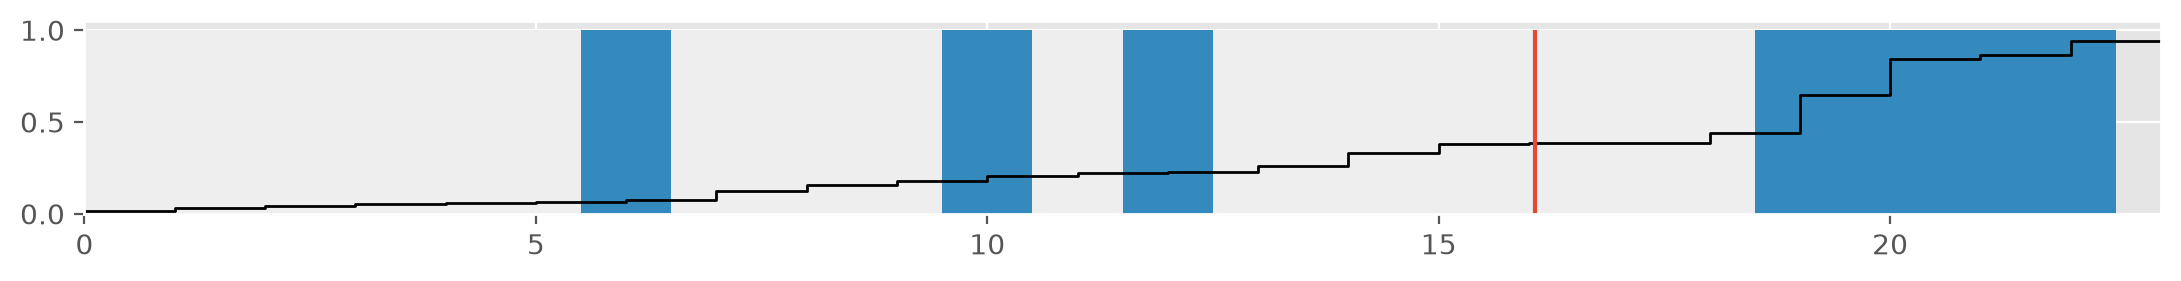

In [68]:

from separation_plot import separation_plot
# plt.tight_layout()
figsize(11., 1.5)
separation_plot(posterior_probability, D)



那条蜿蜒的曲线就是排好序的概率,蓝色的竖条代表发生了缺陷,空白处(乐观一点的读者可以看作灰色条)代表没有发生缺陷。随着概率上升,可以看到出现缺陷的情况也越来越多。图的右侧说明,当后验概率较大(曲线接近 1)时,更容易观测到实际发生的缺陷。这是一种好的表现——理想情况下,所有蓝色的竖条都*应该*集中在右侧,任何偏离这一点的情况都反映出模型的预测有所遗漏。

黑色竖线表示按照该模型,我们应该观测到的缺陷数量的期望值。这可以让读者直观地看出,模型预测的事件总数,和数据中实际发生的事件数量相比如何。

把它和其他模型的分离图放在一起比较,会更有信息量。下面我们把我们的模型(最上面)和另外三个模型进行对比:

1. 完美模型:如果真的发生了缺陷,就预测后验概率为 1。
2. 完全随机模型:不管温度是多少,都预测随机的概率。
3. 常数模型:即 $P(D = 1 \; | \; t) = c, \;\; \forall t$。$c$ 的最佳选择是观测到的缺陷频率,本例中是 7/23。


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20381 (\N{CJK UNIFIED IDEOGRAPH-4F9D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 36182 (\N{CJK UNIFIED IDEOGRAPH-8D56}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20381 (\N{CJK UNIFIED IDEOGRAPH-4F9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36182 (\N{CJK UNIFIED IDEOGRAPH-8D56}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 

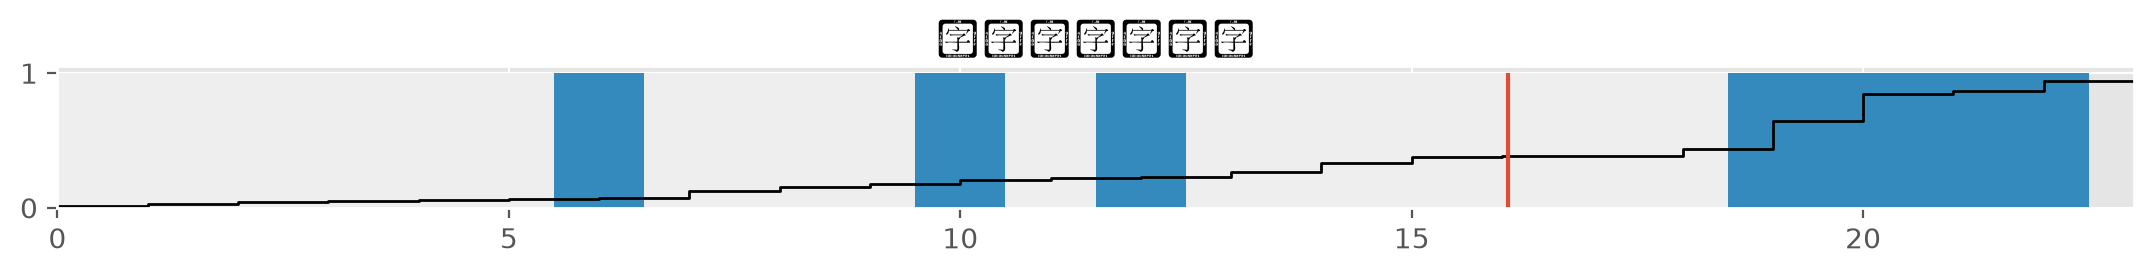

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 32654 (\N{CJK UNIFIED IDEOGRAPH-7F8E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


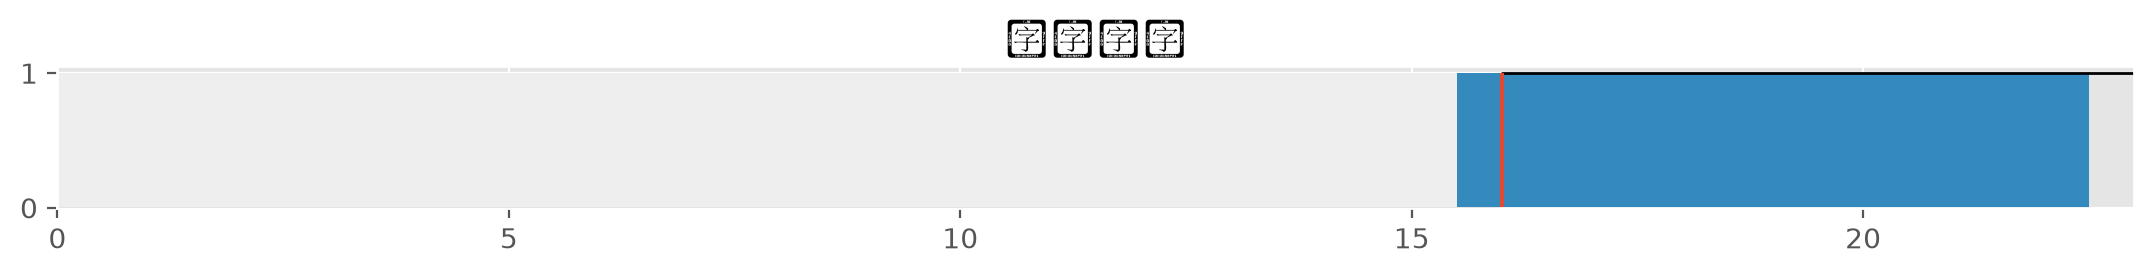

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


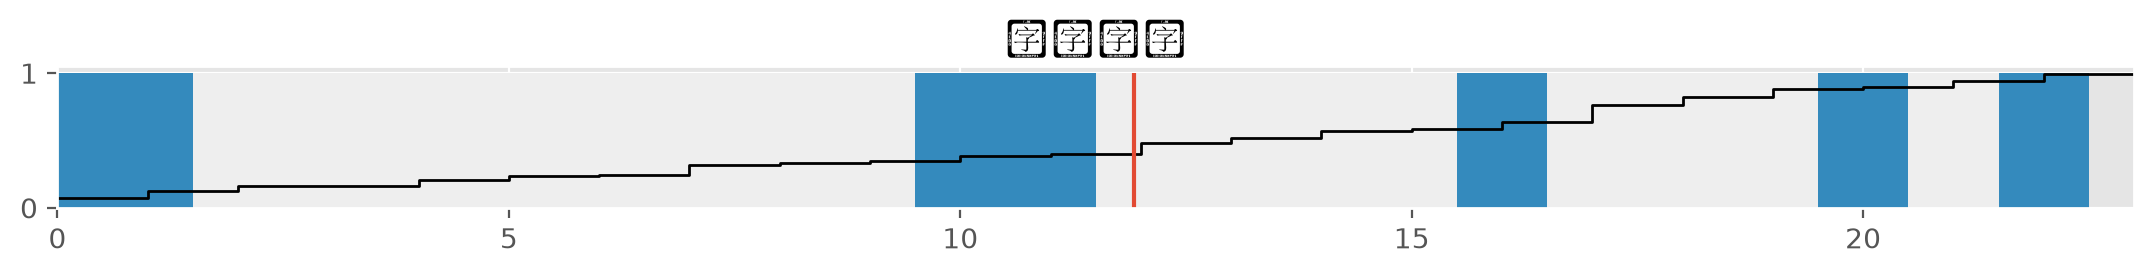

/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


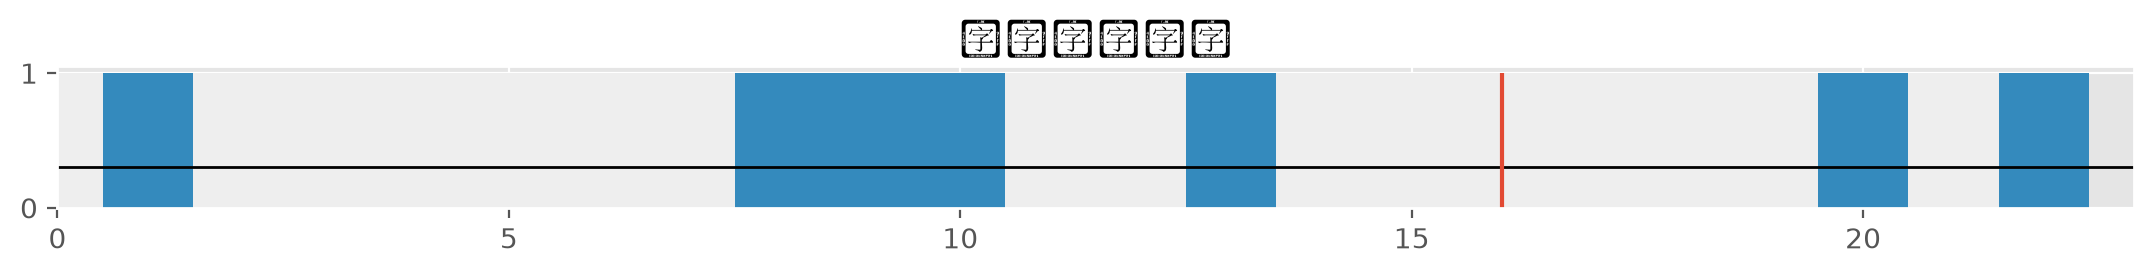

In [69]:

figsize(11., 1.25)

# 我们这个依赖温度的模型
separation_plot(posterior_probability, D)
plt.title("依赖温度的模型")

# 完美模型
# 也就是说, 缺陷概率恰好等于是否真的发生了缺陷。
p = D
separation_plot(p, D)
plt.title("完美模型")

# 随机预测
p = np.random.rand(23)
separation_plot(p, D)
plt.title("随机模型")

# 常数模型
constant_prob = 7. / 23 * np.ones(23)
separation_plot(constant_prob, D)
plt.title("常数预测模型");



在随机模型中,可以看到随着概率增大,缺陷并没有向右侧聚集的趋势。常数模型也是类似的情况。

完美模型的概率曲线不太容易看清,因为它紧贴在图形的顶部和底部。当然,完美模型只是用来做演示的,我们无法从中得出任何真正的科学推断。



##### 习题

1. 试着在作弊例子里代入一些极端的观测值。如果我们观测到 25 个肯定回答会怎样?10 个?50 个?



2. 试着把 $\alpha$ 的样本和 $\beta$ 的样本画在一起。为什么得到的图会长这样?


/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20160 (\N{CJK UNIFIED IDEOGRAPH-4EC0}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 36825 (\N{CJK UNIFIED IDEOGRAPH-8FD9}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/ai/Projects/bmh/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 24352 (\N{CJK UNIFIED IDEOGRAPH-5F20}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

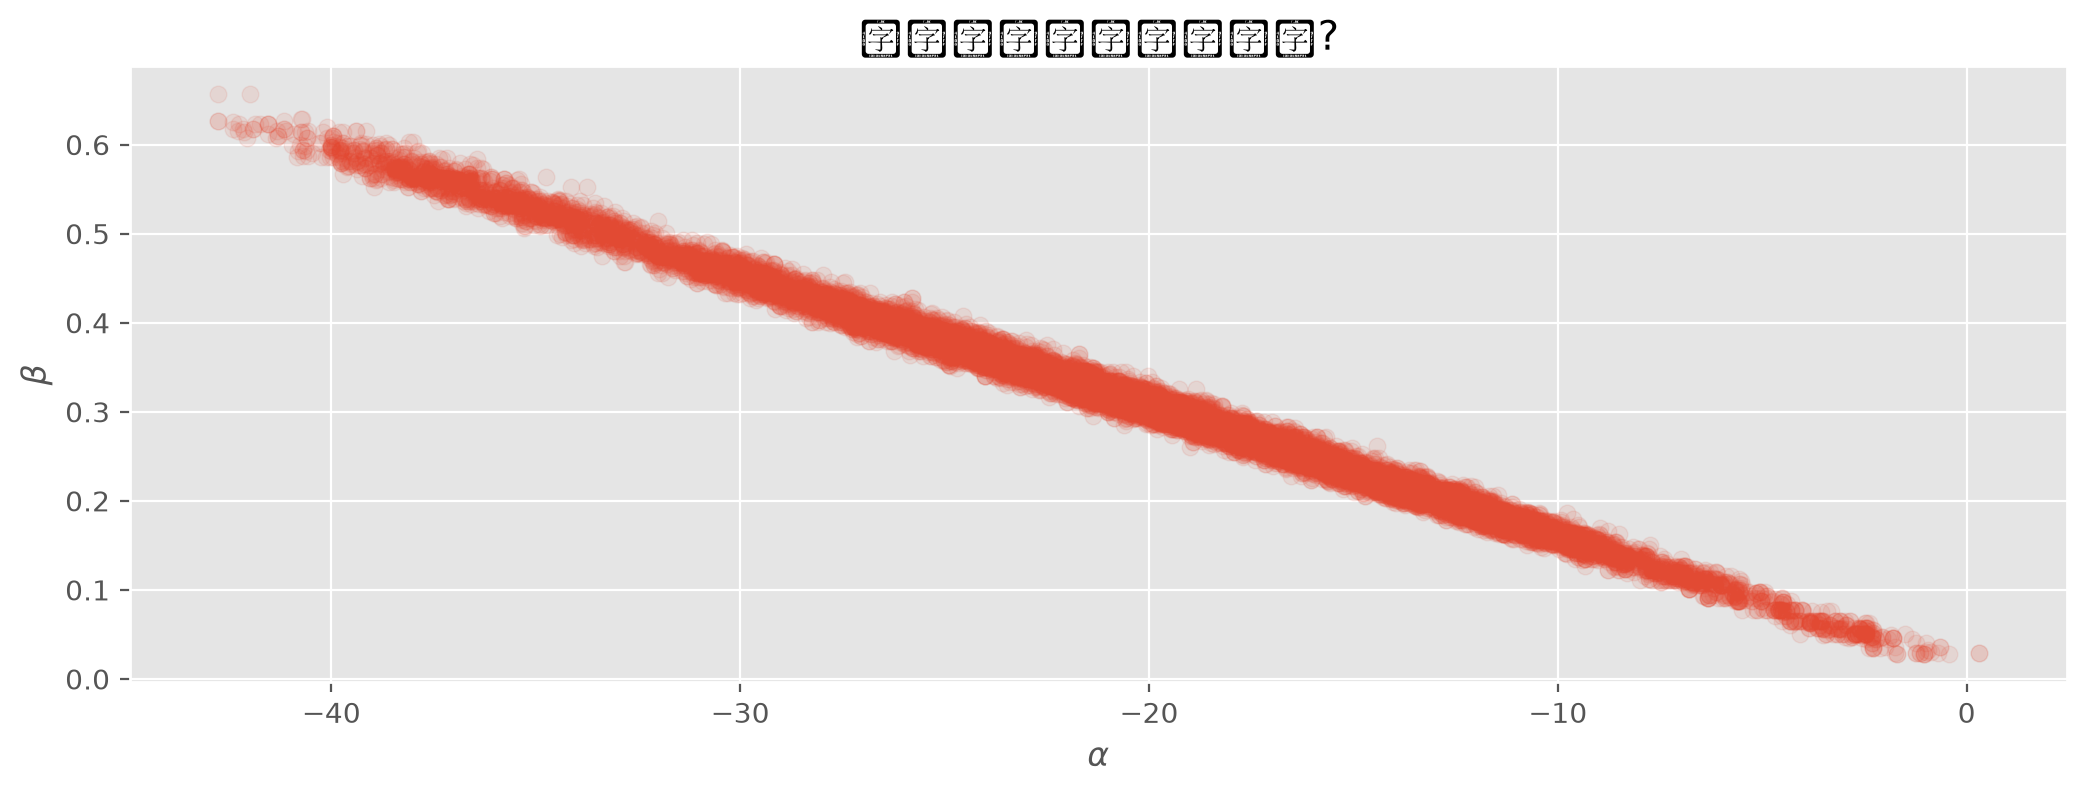

In [70]:

# 在这里写你的代码。
figsize(12.5, 4)

plt.scatter(alpha_samples, beta_samples, alpha=0.1)
plt.title("为什么这张图会长这样?")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$");



### 参考文献

- [1] Dalal, Fowlkes and Hoadley (1989), JASA, 84, 945-957.
- [2] German Rodriguez. Datasets. In WWS509. Retrieved 30/01/2013, from <http://data.princeton.edu/wws509/datasets/#smoking>。
- [3] McLeish, Don, and Cyntha Struthers. STATISTICS 450/850 Estimation and Hypothesis Testing. Winter 2012. Waterloo, Ontario: 2012. Print.
- [4] Fonnesbeck, Christopher. "Building Models." PyMC-Devs. N.p., n.d. Web. 26 Feb 2013.
- [5] Cronin, Beau. "Why Probabilistic Programming Matters." 24 Mar 2013.
- [6] S.P. Brooks, E.A. Catchpole, and B.J.T. Morgan. Bayesian animal survival estimation. Statistical Science, 15: 357-376, 2000.
- [7] Gelman, Andrew. "Philosophy and the practice of Bayesian statistics." British Journal of Mathematical and Statistical Psychology. (2012).
- [8] Greenhill, Brian, Michael D. Ward, and Audrey Sacks. "The Separation Plot: A New Visual Method for Evaluating the Fit of Binary Models." American Journal of Political Science. 55.No.4 (2011).
